In [54]:
### to create mba version of the plot using the new code

In [55]:
## automatically reload 
%reload_ext autoreload
%autoreload 2

In [56]:
import sys
sys.path.insert(0, "src")
import matplotlib.pyplot as plt
import numpy as np
import NEOMOD3 as nm3
import NEOfaster as nf
import neoscore as nsc
import S3Marray as sm
import S3M_fullversion as smfull
import trojans as tjn
import neoonlyS3M as neo3m

In [57]:
s3m = sm.define_s3m()

['S1_00.s3m', 'S1_01.s3m', 'S1_02.s3m', 'S1_03.s3m', 'S1_04.s3m', 'S1_05.s3m', 'S1_06.s3m', 'S1_07.s3m', 'S1_08.s3m', 'S1_09.s3m', 'S1_10.s3m', 'S1_11.s3m', 'S1_12.s3m', 'S1_13.s3m']
The final df is done.


In [58]:
s3m

,OID,FORMAT,q,e,i,node,argperi,t_p,H,t_0,INDEX,N_PAR,MOID,COMPCODE,a
0,S1000000a,COM,3.01822,0.05208,22.56035,211.00286,335.42134,51575.94061,14.20,54800.0,1,6,-1,Python,3.184045
1,S1000001a,COM,2.10974,0.07518,4.91571,209.40298,322.66447,54205.77161,20.57,54800.0,1,6,-1,Python,2.281244
2,S1000002a,COM,2.80523,0.07777,1.24945,112.52284,139.86858,54468.71747,14.65,54800.0,1,6,-1,Python,3.041790
3,S1000003a,COM,2.10917,0.13219,1.46615,266.54621,232.24412,54212.16304,19.58,54800.0,1,6,-1,Python,2.430451
4,S1000004a,COM,2.17676,0.19949,12.92422,162.14580,192.22312,51895.46586,10.56,54800.0,1,6,-1,Python,2.719216
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13883356,S10d5plza,COM,1.29977,0.58220,20.58311,180.18060,248.72915,54117.83912,26.54,54800.0,1,6,-1,Python,3.110986
13883357,S10d5vtGa,COM,1.31752,0.28101,11.62774,160.50980,98.45125,53387.64646,26.28,54800.0,1,6,-1,Python,1.832459
13883358,S10d5zr1a,COM,1.31100,0.41152,21.99857,249.34945,265.76277,52433.74417,26.41,54800.0,1,6,-1,Python,2.227773
13883359,S10d5zPua,COM,1.31109,0.52347,28.61382,322.50347,190.09049,51540.29687,26.44,54800.0,1,6,-1,Python,2.751327


In [59]:
s3m,array4D_s3m, H_center_s3m, a_center_s3m, e_center_s3m, i_center_s3m = sm.s3m_array(s3m)

In [60]:
scorer_mba_s3m = nsc.NEOMODScorer(array4D_s3m, H_center_s3m, a_center_s3m, e_center_s3m, i_center_s3m)

Starting computation...


Computing vlambda grid: 100%|██████████| 31/31 [02:05<00:00,  4.05s/it]

Computation complete!


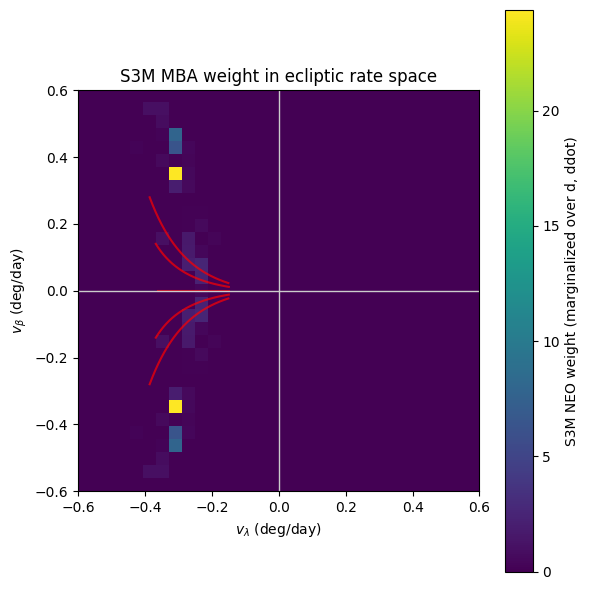

In [61]:
import sys
sys.path.insert(0, "src")
import numpy as np
import matplotlib.pyplot as plt
import neoscore as nsc
from tqdm import tqdm

# Observation params
obstime_str = "2025-09-23T00:00:00"
ra0_deg, dec0_deg = 0.0, 0.0
mag = 24.0

def comp_sum_with_scorer():
    """
    Compute marginalized weights over (vlambda, vbeta) grid using the scorer.
    """
    N_rate = 31
    vlam_min, vlam_max = -0.6, 0.6
    vbet_min, vbet_max = -0.6, 0.6
    vlam_vals = np.linspace(vlam_min, vlam_max, N_rate)
    vbet_vals = np.linspace(vbet_min, vbet_max, N_rate)
    
    K = np.zeros((len(vbet_vals), len(vlam_vals)), dtype=float)
    
    
    for i, vlam in enumerate(tqdm(vlam_vals, desc="Computing vlambda grid")):
        for j, vbet in enumerate(vbet_vals):
            # Convert ecliptic rates to RA/Dec rates
            dra, ddec = nsc.ecliptic_rates_to_radec_rates1(
                ra0_deg, dec0_deg, vlam, vbet, obstime_str
            )
            
            # Use the scorer's marginalization method
            w_int = scorer_mba_s3m.marginalize_over_distance(
                obstime_str=obstime_str,
                ra_deg=ra0_deg,
                dec_deg=dec0_deg,
                dra_deg_per_day=dra,
                ddec_deg_per_day=ddec,
                mag=mag
            )
            
            K[j, i] = w_int
    
    extent = [vlam_vals[0], vlam_vals[-1], vbet_vals[0], vbet_vals[-1]]
    return K, extent, vlam_vals, vbet_vals

# Compute the grid
print("Starting computation...")
K, extent, vlam_vals, vbet_vals = comp_sum_with_scorer()
print("Computation complete!")

# Prediction function 
vE_deg_per_day = 0.986  # Earth's orbital speed

def prediction_vlam_vbet(R_au, i_deg, phi_deg, beta_deg=0.0):
    """Predict ecliptic rates for given orbital parameters."""
    i = np.deg2rad(i_deg)
    phi = np.deg2rad(phi_deg)
    beta = np.deg2rad(beta_deg)
    
    theta = phi - np.arcsin(np.sin(phi) / R_au)
    Delta = np.sqrt(R_au**2 + 1.0 - 2.0 * R_au * np.cos(theta))
    
    v_factor = vE_deg_per_day / np.sqrt(R_au)
    vx = v_factor * np.cos(i) * np.sin(theta)
    vy = v_factor * np.cos(i) * np.cos(theta)
    vz = v_factor * np.sin(i)
    
    vlam = (np.sin(phi) * vx + np.cos(phi) * (vy - vE_deg_per_day)) / Delta
    vbet = (-np.sin(beta) * np.cos(phi) * vx
            + np.sin(beta) * np.sin(phi) * (vy - vE_deg_per_day)
            + np.cos(beta) * vz) / Delta
    
    return vlam, vbet

# Generate prediction curves for different inclinations
phi_deg = 0.0  # opposition
beta_deg = 0.0  # on the ecliptic
i_list = np.arange(-10.0, 15.0, 5.0)  # -10, -5, 0, 5, 10
R_vals = np.linspace(1.5, 4.5, 800)  # AU

i_lines = []
for i_deg in i_list:
    vlam_arr = []
    vbet_arr = []
    for R in R_vals:
        vlam, vbet = prediction_vlam_vbet(R, i_deg, phi_deg, beta_deg)
        vlam_arr.append(vlam)
        vbet_arr.append(vbet)
    i_lines.append((np.array(vlam_arr), np.array(vbet_arr), i_deg))


plt.figure(figsize=(6.0, 6.0))
im = plt.imshow(K, origin="lower", extent=extent, cmap="viridis", aspect="equal")
plt.colorbar(label="S3M NEO weight (marginalized over d, ddot)")

# Plot prediction curves
for vlam_arr, vbet_arr, i_deg in i_lines:
    plt.plot(vlam_arr, vbet_arr, 'r-', lw=1.5, alpha=0.7, 
             label=f'i={i_deg}°' if i_deg == i_list[0] else '')

plt.axhline(0, color="0.8", lw=1)
plt.axvline(0, color="0.8", lw=1)
plt.xlabel(r"$v_\lambda$ (deg/day)")
plt.ylabel(r"$v_\beta$ (deg/day)")
plt.xlim(-0.6, 0.6)
plt.ylim(-0.6, 0.6)
plt.title("S3M MBA weight in ecliptic rate space")
plt.tight_layout()
plt.show()

In [62]:
import sys
sys.path.insert(0, "src")
from astropy.time import Time
import astropy.units as u
from astropy.coordinates import get_sun, SkyCoord

import neoscore as nsc  

def anti_sun_radec_icrs(obstime_str):
    """
    Return anti-Sun direction as (ra_deg, dec_deg) in ICRS at obstime.
    Get Sun direction in ICRS, negate cartesian, convert back to spherical.
    """
    t = Time(obstime_str)
    sun = get_sun(t).icrs

    # Sun cartesian unit vector 
    cart = sun.cartesian

    # Built anti-sun as cartesian in ICRS, then forced spherical representation
    anti = SkyCoord(
        x=-cart.x, y=-cart.y, z=-cart.z,
        representation_type="cartesian",
        frame="icrs",
        obstime=t
    ).icrs  # it should be an ICRS SkyCoord

    # Converting to spherical quantities
    ra = anti.spherical.lon.to_value(u.deg)   # RA
    dec = anti.spherical.lat.to_value(u.deg)  # Dec
    return ra, dec


def vector_test(scorer, obstime_str, d_au=1.5, ddot_kms=0.0, dt_sec=600.0):
    """
    Anti-sun pointing, vlam=vbeta=0, known d and ddot.
    Prints vectors and small-dt angular drift.
    """

    # 1) Anti-Sun pointing in RA/Dec
    ra0_deg, dec0_deg = anti_sun_radec_icrs(obstime_str)

    # 2) Given ecliptic rates
    vlam = 0.0
    vbet = 0.0

    # 3) Convert (vlam, vbet) -> (dra, ddec) using the function from neoscore.py
    dra_deg_day, ddec_deg_day = nsc.ecliptic_rates_to_radec_rates1(
        ra0_deg, dec0_deg, vlam, vbet, obstime_str
    )

    # 4) Build geocentric state like the scorer does
    l_hat, v_hat = scorer._compute_unit_vectors(ra0_deg, dec0_deg, dra_deg_day, ddec_deg_day)

    # In the class, _observables_to_geocentric_state expects ddot_kms and d_au to behave like scalars.
    r_geo, v_geo = scorer._observables_to_geocentric_state(l_hat, v_hat, d_au, ddot_kms)

    # Make 1D vectors
    l_hat = np.asarray(l_hat).reshape(3,)
    v_hat = np.asarray(v_hat).reshape(3,)
    r_geo = np.asarray(r_geo).reshape(-1, 3)[0]   
    v_geo = np.asarray(v_geo).reshape(-1, 3)[0]

    # 5) Expected Line of Sight vector from (ra0,dec0)
    ra = np.deg2rad(ra0_deg)
    dec = np.deg2rad(dec0_deg)
    expected = np.array([np.cos(dec)*np.cos(ra),
                         np.cos(dec)*np.sin(ra),
                         np.sin(dec)], dtype=float)

    l_hat_n = l_hat / np.linalg.norm(l_hat)
    expected_n = expected / np.linalg.norm(expected)

    dot = float(np.clip(np.dot(l_hat_n, expected_n), -1.0, 1.0))
    ang_deg = np.rad2deg(np.arccos(dot))

    # 6) Check the conversion back: RA/Dec rates -> ecliptic rates (should come back as 0, if not Panik)
    vlam_back, vbet_back = nsc.radec_rates_to_ecliptic_rates(
        ra0_deg, dec0_deg, dra_deg_day, ddec_deg_day
    )

    # 7) Propagation drift check
    r2 = r_geo + v_geo * dt_sec
    u1 = r_geo / np.linalg.norm(r_geo)
    u2 = r2 / np.linalg.norm(r2)
    drift_deg = np.rad2deg(np.arccos(float(np.clip(np.dot(u1, u2), -1.0, 1.0))))

    print("anti-Sun, vlam=vbeta=0")
    print(f"obstime: {obstime_str}")
    print(f"anti-sun RA,Dec (deg): {ra0_deg:.6f}, {dec0_deg:.6f}")
    print()
    print("Input ecliptic rates (deg/day):")
    print(f"  vlam={vlam:.6f}, vbeta={vbet:.6f}")
    print("Converted ICRS rates (deg/day):")
    print(f"  dra={dra_deg_day:.12e}, ddec={ddec_deg_day:.12e}")
    print("Returned ecliptic rates (deg/day):")
    print(f"  vlam_back={float(vlam_back):.12e}, vbeta_back={float(vbet_back):.12e}")
    print()
    print("LOS unit vector check:")
    print(f"  l_hat    = {l_hat_n}")
    print(f"  expected = {expected_n}")
    print(f"  angle(l_hat, expected) [deg] = {ang_deg:.12e}")
    print()
    print(f"Geocentric state at d={d_au:.3f} AU, ddot={ddot_kms:.3f} km/s:")
    print(f"  r_geo (km)  = {r_geo}")
    print(f"  v_geo (km/s)= {v_geo}")
    print(f"Direction drift over dt={dt_sec:.1f} s (deg): {drift_deg:.12e}")

    return {
        "ra0_deg": ra0_deg, "dec0_deg": dec0_deg,
        "dra_deg_day": dra_deg_day, "ddec_deg_day": ddec_deg_day,
        "vlam_back": float(vlam_back), "vbet_back": float(vbet_back),
        "angle_deg": ang_deg, "drift_deg": drift_deg,
        "r_geo": r_geo, "v_geo": v_geo,
    }



out = vector_test(scorer_mba_s3m, obstime_str, d_au=1.5, ddot_kms=0.0, dt_sec=600.0)


anti-Sun, vlam=vbeta=0
obstime: 2025-09-23T00:00:00
anti-sun RA,Dec (deg): 53.359612, 17.899506

Input ecliptic rates (deg/day):
  vlam=0.000000, vbeta=0.000000
Converted ICRS rates (deg/day):
  dra=0.000000000000e+00, ddec=0.000000000000e+00
Returned ecliptic rates (deg/day):
  vlam_back=4.028038770723e-05, vbeta_back=3.111330995237e-07

LOS unit vector check:
  l_hat    = [0.56790421 0.76355862 0.30734841]
  expected = [0.56790421 0.76355862 0.30734841]
  angle(l_hat, expected) [deg] = 0.000000000000e+00

Geocentric state at d=1.500 AU, ddot=0.000 km/s:
  r_geo (km)  = [1.27435891e+08 1.71340115e+08 6.89680021e+07]
  v_geo (km/s)= [0. 0. 0.]
Direction drift over dt=600.0 s (deg): 8.537736462516e-07


In [63]:
import sys
sys.path.insert(0, "src")
from astropy.time import Time
import astropy.units as u
from astropy.coordinates import get_sun, SkyCoord

import neoscore as nsc  

def anti_sun_radec_icrs(obstime_str):
    """
    Return anti-Sun direction as (ra_deg, dec_deg) in ICRS at obstime.
    Get Sun direction in ICRS, negate cartesian, convert back to spherical.
    """
    t = Time(obstime_str)
    sun = get_sun(t).gcrs

    # Sun cartesian unit vector 
    cart = sun.cartesian

    # Built anti-sun as cartesian in ICRS, then forced spherical representation
    anti = SkyCoord(
        x=-cart.x, y=-cart.y, z=-cart.z,
        representation_type="cartesian",
        frame="gcrs",
        obstime=t
    )  # it should be an ICRS SkyCoord

    # Converting to spherical quantities
    ra = anti.spherical.lon.to_value(u.deg)   # RA
    dec = anti.spherical.lat.to_value(u.deg)  # Dec
    return ra, dec


def vector_test(scorer, obstime_str, d_au=1.5, ddot_kms=0.0, dt_sec=600.0):
    """
    Anti-sun pointing, vlam=vbeta=0, known d and ddot.
    Prints vectors and small-dt angular drift.
    """

    # 1) Anti-Sun pointing in RA/Dec
    ra0_deg, dec0_deg = anti_sun_radec_icrs(obstime_str)

    # 2) Given ecliptic rates
    vlam = 0.0
    vbet = 0.0

    # 3) Convert (vlam, vbet) -> (dra, ddec) using the function from neoscore.py
    dra_deg_day, ddec_deg_day = nsc.ecliptic_rates_to_radec_rates1(
        ra0_deg, dec0_deg, vlam, vbet, obstime_str
    )

    # 4) Build geocentric state like the scorer does
    l_hat, v_hat = scorer._compute_unit_vectors(ra0_deg, dec0_deg, dra_deg_day, ddec_deg_day)

    # In the class, _observables_to_geocentric_state expects ddot_kms and d_au to behave like scalars.
    r_geo, v_geo = scorer._observables_to_geocentric_state(l_hat, v_hat, d_au, ddot_kms)

    # Make 1D vectors
    l_hat = np.asarray(l_hat).reshape(3,)
    v_hat = np.asarray(v_hat).reshape(3,)
    r_geo = np.asarray(r_geo).reshape(-1, 3)[0]   
    v_geo = np.asarray(v_geo).reshape(-1, 3)[0]

    # 5) Expected Line of Sight vector from (ra0,dec0)
    ra = np.deg2rad(ra0_deg)
    dec = np.deg2rad(dec0_deg)
    expected = np.array([np.cos(dec)*np.cos(ra),
                         np.cos(dec)*np.sin(ra),
                         np.sin(dec)], dtype=float)

    l_hat_n = l_hat / np.linalg.norm(l_hat)
    expected_n = expected / np.linalg.norm(expected)

    dot = float(np.clip(np.dot(l_hat_n, expected_n), -1.0, 1.0))
    ang_deg = np.rad2deg(np.arccos(dot))

    # 6) Check the conversion back: RA/Dec rates -> ecliptic rates (should come back as 0, if not Panik)
    vlam_back, vbet_back = nsc.radec_rates_to_ecliptic_rates(
        ra0_deg, dec0_deg, dra_deg_day, ddec_deg_day
    )

    # 7) Propagation drift check
    r2 = r_geo + v_geo * dt_sec
    u1 = r_geo / np.linalg.norm(r_geo)
    u2 = r2 / np.linalg.norm(r2)
    drift_deg = np.rad2deg(np.arccos(float(np.clip(np.dot(u1, u2), -1.0, 1.0))))

    print("anti-Sun, vlam=vbeta=0")
    print(f"obstime: {obstime_str}")
    print(f"anti-sun RA,Dec (deg): {ra0_deg:.6f}, {dec0_deg:.6f}")
    print()
    print("Input ecliptic rates (deg/day):")
    print(f"  vlam={vlam:.6f}, vbeta={vbet:.6f}")
    print("Converted ICRS rates (deg/day):")
    print(f"  dra={dra_deg_day:.12e}, ddec={ddec_deg_day:.12e}")
    print("Returned ecliptic rates (deg/day):")
    print(f"  vlam_back={float(vlam_back):.12e}, vbeta_back={float(vbet_back):.12e}")
    print()
    print("LOS unit vector check:")
    print(f"  l_hat    = {l_hat_n}")
    print(f"  expected = {expected_n}")
    print(f"  angle(l_hat, expected) [deg] = {ang_deg:.12e}")
    print()
    print(f"Geocentric state at d={d_au:.3f} AU, ddot={ddot_kms:.3f} km/s:")
    print(f"  r_geo (km)  = {r_geo}")
    print(f"  v_geo (km/s)= {v_geo}")
    print(f"Direction drift over dt={dt_sec:.1f} s (deg): {drift_deg:.12e}")

    return {
        "ra0_deg": ra0_deg, "dec0_deg": dec0_deg,
        "dra_deg_day": dra_deg_day, "ddec_deg_day": ddec_deg_day,
        "vlam_back": float(vlam_back), "vbet_back": float(vbet_back),
        "angle_deg": ang_deg, "drift_deg": drift_deg,
        "r_geo": r_geo, "v_geo": v_geo,
    }



out = vector_test(scorer_mba_s3m, obstime_str, d_au=1.5, ddot_kms=0.0, dt_sec=600.0)


anti-Sun, vlam=vbeta=0
obstime: 2025-09-23T00:00:00
anti-sun RA,Dec (deg): 359.881947, -0.051431

Input ecliptic rates (deg/day):
  vlam=0.000000, vbeta=0.000000
Converted ICRS rates (deg/day):
  dra=0.000000000000e+00, ddec=0.000000000000e+00
Returned ecliptic rates (deg/day):
  vlam_back=4.028681508555e-05, vbeta_back=3.113450785642e-08

LOS unit vector check:
  l_hat    = [ 9.99997474e-01 -2.06041694e-03 -8.97645677e-04]
  expected = [ 9.99997474e-01 -2.06041694e-03 -8.97645677e-04]
  angle(l_hat, expected) [deg] = 0.000000000000e+00

Geocentric state at d=1.500 AU, ddot=0.000 km/s:
  r_geo (km)  = [ 2.24396239e+08 -4.62350980e+05 -2.01428823e+05]
  v_geo (km/s)= [0. 0. 0.]
Direction drift over dt=600.0 s (deg): 8.537736462516e-07


#### Same thing but not converting sun position to ICRS in order to check the conversions

In [64]:
from astropy.coordinates import GeocentricTrueEcliptic

def radec_rates_to_ecliptic_rates_at_obstime(ra_deg, dec_deg, dra_deg_day, ddec_deg_day, obstime_str):
    t = Time(obstime_str)
    sc_eq = SkyCoord(
        ra=ra_deg * u.deg,
        dec=dec_deg * u.deg,
        pm_ra_cosdec=dra_deg_day * u.deg/u.day,
        pm_dec=ddec_deg_day * u.deg/u.day,
        frame=GCRS(obstime=t)
    )
    sc_ecl = sc_eq.transform_to(GeocentricTrueEcliptic(obstime=t))
    vlam = sc_ecl.pm_lon_coslat.to(u.deg/u.day).value
    vbeta = sc_ecl.pm_lat.to(u.deg/u.day).value
    return vlam, vbeta


In [65]:
import sys
sys.path.insert(0, "src")
from astropy.coordinates import GCRS

# Get sun coords in GCRS (no ICRS forced conversion)
def anti_sun_radec_gcrs(obstime_str):
    t = Time(obstime_str)
    sun_gcrs = get_sun(t).transform_to(GCRS(obstime=t))
    cart = sun_gcrs.cartesian

    anti_gcrs = SkyCoord(
        x=-cart.x, y=-cart.y, z=-cart.z,
        representation_type="cartesian",
        frame=GCRS(obstime=t)
    )

    ra = anti_gcrs.spherical.lon.to_value(u.deg)
    dec = anti_gcrs.spherical.lat.to_value(u.deg)
    return ra, dec

# Conversion of RA/dec rates to ecliptic using obstime instead of without
def radec_rates_to_ecliptic_rates_at_obstime(ra_deg, dec_deg, dra_deg_day, ddec_deg_day, obstime_str):
    t = Time(obstime_str)
    sc_eq = SkyCoord(
        ra=ra_deg * u.deg,
        dec=dec_deg * u.deg,
        pm_ra_cosdec=dra_deg_day * u.deg/u.day,
        pm_dec=ddec_deg_day * u.deg/u.day,
        frame=GCRS(obstime=t)
    )
    sc_ecl = sc_eq.transform_to(GeocentricTrueEcliptic(obstime=t))
    vlam = sc_ecl.pm_lon_coslat.to(u.deg/u.day).value
    vbeta = sc_ecl.pm_lat.to(u.deg/u.day).value
    return vlam, vbeta


def vector_test(scorer, obstime_str, vlam=0.0, vbet=0.0, d_au=1.5, ddot_kms=0.0, dt_sec=600.0):
    # Anti-Sun pointing in RA/Dec (GCRS)
    ra0_deg, dec0_deg = anti_sun_radec_gcrs(obstime_str)

    # Convert (vlam, vbet) -> (dra, ddec) using the neoscorer function
    dra_deg_day, ddec_deg_day = nsc.ecliptic_rates_to_radec_rates1(
        ra0_deg, dec0_deg, vlam, vbet, obstime_str
    )

    # Build geocentric state using functions from scorer
    l_hat, v_hat = scorer._compute_unit_vectors(ra0_deg, dec0_deg, dra_deg_day, ddec_deg_day)
    r_geo, v_geo = scorer._observables_to_geocentric_state(l_hat, v_hat, d_au, ddot_kms)

    # Reshape
    l_hat = np.asarray(l_hat).reshape(3,)
    r_geo = np.asarray(r_geo).reshape(-1, 3)[0]
    v_geo = np.asarray(v_geo).reshape(-1, 3)[0]

    # Expected LOS vector from (ra0, dec0)
    ra = np.deg2rad(ra0_deg)
    dec = np.deg2rad(dec0_deg)
    expected = np.array([np.cos(dec)*np.cos(ra),
                         np.cos(dec)*np.sin(ra),
                         np.sin(dec)], dtype=float)

    l_hat_n = l_hat / np.linalg.norm(l_hat)
    expected_n = expected / np.linalg.norm(expected)
    ang_deg = np.rad2deg(np.arccos(float(np.clip(np.dot(l_hat_n, expected_n), -1.0, 1.0))))

    # Convert RA/Dec rates -> ecliptic rates (at same obstime, in GCRS)
    vlam_back, vbet_back = radec_rates_to_ecliptic_rates_at_obstime(
        ra0_deg, dec0_deg, dra_deg_day, ddec_deg_day, obstime_str
    )

    # Drift check
    r2 = r_geo + v_geo * dt_sec
    u1 = r_geo / np.linalg.norm(r_geo)
    u2 = r2 / np.linalg.norm(r2)
    drift_deg = np.rad2deg(np.arccos(float(np.clip(np.dot(u1, u2), -1.0, 1.0))))

    
    print("=== anti-Sun rate sanity test (GCRS) ===")
    print(f"obstime: {obstime_str}")
    print(f"anti-sun RA,Dec (deg): {ra0_deg:.6f}, {dec0_deg:.6f}")
    print()
    print("Input ecliptic rates (deg/day):")
    print(f"  vlam={vlam:.6f}, vbeta={vbet:.6f}")
    print("Converted equatorial rates (deg/day):")
    print(f"  dra={dra_deg_day:.12e}, ddec={ddec_deg_day:.12e}")
    print("Returned ecliptic rates (deg/day):")
    print(f"  vlam_back={float(vlam_back):.12e}, vbeta_back={float(vbet_back):.12e}")
    print()
    print("LOS unit vector check:")
    print(f"  angle(l_hat, expected) [deg] = {ang_deg:.12e}")
    print()
    print(f"Geocentric state at d={d_au:.3f} AU, ddot={ddot_kms:.3f} km/s:")
    print(f"  r_geo (km)  = {r_geo}")
    print(f"  v_geo (km/s)= {v_geo}")
    print(f"Direction drift over dt={dt_sec:.1f} s (deg): {drift_deg:.12e}")

    return {
        "ra0_deg": ra0_deg, "dec0_deg": dec0_deg,
        "dra_deg_day": dra_deg_day, "ddec_deg_day": ddec_deg_day,
        "vlam_back": float(vlam_back), "vbet_back": float(vbet_back),
        "angle_deg": ang_deg, "drift_deg": drift_deg,
        "r_geo": r_geo, "v_geo": v_geo,
    }


# For v_lam, v_beta = (0,0) 
out00 = vector_test(scorer_mba_s3m, obstime_str, vlam=0.0, vbet=0.0)
print()
print()
print()
# For v_lam, v_beta = (30,45) 
out3045 = vector_test(scorer_mba_s3m, obstime_str, vlam=30.0, vbet=45.0)


=== anti-Sun rate sanity test (GCRS) ===
obstime: 2025-09-23T00:00:00
anti-sun RA,Dec (deg): 359.881947, -0.051431

Input ecliptic rates (deg/day):
  vlam=0.000000, vbeta=0.000000
Converted equatorial rates (deg/day):
  dra=0.000000000000e+00, ddec=0.000000000000e+00
Returned ecliptic rates (deg/day):
  vlam_back=4.028681508555e-05, vbeta_back=3.113450785642e-08

LOS unit vector check:
  angle(l_hat, expected) [deg] = 0.000000000000e+00

Geocentric state at d=1.500 AU, ddot=0.000 km/s:
  r_geo (km)  = [ 2.24396239e+08 -4.62350980e+05 -2.01428823e+05]
  v_geo (km/s)= [0. 0. 0.]
Direction drift over dt=600.0 s (deg): 8.537736462516e-07



=== anti-Sun rate sanity test (GCRS) ===
obstime: 2025-09-23T00:00:00
anti-sun RA,Dec (deg): 359.881947, -0.051431

Input ecliptic rates (deg/day):
  vlam=30.000000, vbeta=45.000000
Converted equatorial rates (deg/day):
  dra=9.624547887716e+00, ddec=5.321999697442e+01
Returned ecliptic rates (deg/day):
  vlam_back=3.000004028681e+01, vbeta_back=4.50000

[getECLposition] ecliptic beta at anti-sun = -0.000234 deg
obstime = 2025-09-23T00:00:00
anti-sun RA,Dec (deg) = 359.881947, -0.051431
ddot= -40.0  score=0.000e+00  a=-0.660  e=2.325  i=0.003  H=19.257
ddot= -20.0  score=0.000e+00  a=-7.112  e=1.188  i=0.002  H=19.257
ddot= -10.0  score=0.000e+00  a=4.801  e=0.625  i=0.003  H=19.257
ddot=   0.0  score=1.760e+02  a=3.015  e=0.164  i=0.004  H=19.257
ddot=  10.0  score=0.000e+00  a=4.353  e=0.570  i=0.006  H=19.257
ddot=  20.0  score=0.000e+00  a=-10.231  e=1.135  i=0.007  H=19.257
ddot=  40.0  score=0.000e+00  a=-0.700  e=2.286  i=0.010  H=19.257
max score = 783.0 at ddot = -1.5 km/s
score at ddot=0 = 176.0


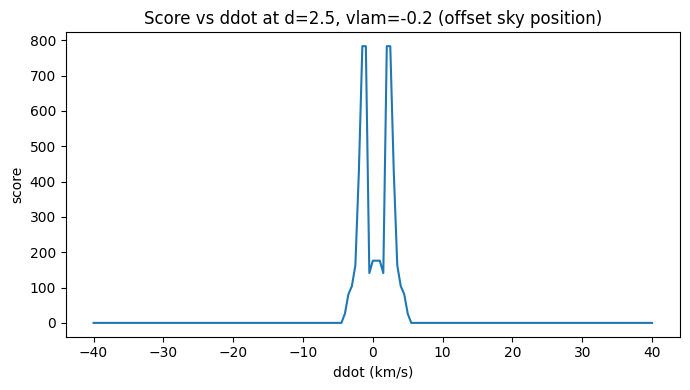

Scanning distance d: 100%|██████████| 60/60 [02:30<00:00,  2.51s/AU]


Total runtime: 2.51 minutes


In [66]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.time import Time
import astropy.units as u
from astropy.coordinates import get_sun, SkyCoord, GeocentricTrueEcliptic, GCRS
from tqdm import tqdm
import time



def anti_sun_radec_icrs(obstime_str):
    """Anti-sun RA/Dec in GCRS at obstime."""
    t = Time(obstime_str)
    sun = get_sun(t)
    cart = sun.cartesian
    anti = SkyCoord(
        x=-cart.x, y=-cart.y, z=-cart.z,
        representation_type="cartesian",
        frame="gcrs",
        obstime=t
    )
    return (
        anti.spherical.lon.to_value(u.deg),
        anti.spherical.lat.to_value(u.deg),
    )



#raAS_deg, decAS_deg = anti_sun_radec_icrs(obstime_str)

#antisun = True
#if antisun:
#    ra0_deg, dec0_deg = raAS_deg, decAS_deg 
#else: 
    # go to ecliptic coord, verify that beta is about 0, and then
    # add 30, 60, and 90 deg to the longitude and rerun with ddot = 0 
    # i.e. use raAS_deg, decAS_deg  to get ra0_deg, dec0_deg  



def getECLposition(raAntisun_deg, decAntisun_deg, obstime_str, longitudeOffset_deg=0.0):
    """
    Take anti-sun (ra,dec) in GCRS at obstime, convert to ecliptic,
    print beta (should be 0), add longitude offset, convert back to GCRS.
    Returns (ra0_deg, dec0_deg).
    """
    t = Time(obstime_str)

    # anti-sun direction as a SkyCoord in GCRS
    sc_gcrs = SkyCoord(ra=raAntisun_deg*u.deg, dec=decAntisun_deg*u.deg,
                       frame=GCRS(obstime=t))

    # convert to geocentric true ecliptic at same obstime
    sc_ecl = sc_gcrs.transform_to(GeocentricTrueEcliptic(obstime=t))

    lam = sc_ecl.lon.wrap_at(360*u.deg).to_value(u.deg)
    beta = sc_ecl.lat.to_value(u.deg)
    print(f"[getECLposition] ecliptic beta at anti-sun = {beta:+.6f} deg")

    # add longitude offset while keeping latitude the same (so go along the ecliptic)
    lam_off = (sc_ecl.lon + longitudeOffset_deg*u.deg).wrap_at(360*u.deg)

    sc_ecl_off = SkyCoord(lon=lam_off, lat=sc_ecl.lat,
                          frame=GeocentricTrueEcliptic(obstime=t))

    # back to GCRS to get RA/Dec 
    sc_back = sc_ecl_off.transform_to(GCRS(obstime=t))
    return sc_back.ra.to_value(u.deg), sc_back.dec.to_value(u.deg)



raAS_deg, decAS_deg = anti_sun_radec_icrs(obstime_str)

longitudeOffset_deg = 0.0  # change to 0, 30, 60, 90 ...

use_offset = True  # switch to false to go back to default settings for anti-sun (or change the offset above to 0)
if use_offset:
    ra0_deg, dec0_deg = getECLposition(raAS_deg, decAS_deg, obstime_str, longitudeOffset_deg)
else:
    ra0_deg, dec0_deg = raAS_deg, decAS_deg

# need these for below ra0_deg, dec0_deg  



print(f"obstime = {obstime_str}")
print(f"anti-sun RA,Dec (deg) = {ra0_deg:.6f}, {dec0_deg:.6f}")

# --- MINI TEST 2: so why are scores all zero at the offset position? print out score elements for specific positions ---
d_test = 2.5
vlam_test = -0.2
vbeta_test = 0.0

dra_test, ddec_test = nsc.ecliptic_rates_to_radec_rates1(
    ra0_deg, dec0_deg, vlam_test, vbeta_test, obstime_str
)

for dd in [-40, -20, -10, 0, 10, 20, 40]:
    out = scorer_mba_s3m.compute_score(
        obstime_str=obstime_str,
        ra_deg=ra0_deg,
        dec_deg=dec0_deg,
        dra_deg_per_day=dra_test,
        ddec_deg_per_day=ddec_test,
        mag=mag,
        d_au=d_test,
        ddot_kms=dd
    )
    print(f"ddot={dd:6.1f}  score={out['score']:.3e}  a={out['a']:.3f}  e={out['e']:.3f}  i={out['i']:.3f}  H={out['H']:.3f}")


# --------- MINI TEST 1: so what does ddot=0 do? --------------------------------------

d_test = 2.5
vlam_test = -0.2
vbeta_test = 0.0

dra_test, ddec_test = nsc.ecliptic_rates_to_radec_rates1(
    ra0_deg, dec0_deg, vlam_test, vbeta_test, obstime_str
)

ddot_grid_test = np.linspace(-40, 40, 161)  # km/s
scores = []

for dd in ddot_grid_test:
    out = scorer_mba_s3m.compute_score(
        obstime_str=obstime_str,
        ra_deg=ra0_deg,
        dec_deg=dec0_deg,
        dra_deg_per_day=dra_test,
        ddec_deg_per_day=ddec_test,
        mag=mag,
        d_au=d_test,
        ddot_kms=dd
    )
    scores.append(out["score"])

scores = np.array(scores)
imax = np.argmax(scores)

print("max score =", scores[imax], "at ddot =", ddot_grid_test[imax], "km/s")
print("score at ddot=0 =", scores[np.argmin(np.abs(ddot_grid_test - 0.0))])

plt.figure(figsize=(7,4))
plt.plot(ddot_grid_test, scores)
plt.xlabel("ddot (km/s)")
plt.ylabel("score")
plt.title(f"Score vs ddot at d={d_test}, vlam={vlam_test} (offset sky position)")
plt.tight_layout()
plt.show()

#--------------------------------------------------------------------
# conversion consistency check at anti-sun 

# pick a representative ecliptic rate
#vlam0, vbet0 = -0.2, 0.0  # deg/day

# forward: (vlam,vbet) -> (dra,ddec)
#dra, ddec = nsc.ecliptic_rates_to_radec_rates1(
#    ra0_deg, dec0_deg, vlam0, vbet0, obstime_str
#)

# backward: (dra,ddec) -> (vlam_back,vbet_back) at SAME obstime
#vlam_back, vbet_back = radec_rates_to_ecliptic_rates_at_obstime(
#    ra0_deg, dec0_deg, dra, ddec, obstime_str
#)

#print("vlam0:", vlam0)
#print("vlam_back:", vlam_back)
#print("diff (vlam_back - vlam0):", vlam_back - vlam0)
#print("vbet0:", vbet0, "vbet_back:", vbet_back)



# Grids

d_grid = np.linspace(1.5, 4.5, 60)          # AU
vlam_grid = np.linspace(-0.6, 0.6, 241)     # deg/day
vbeta_fixed = 0.0
ddot_fixed = 0.0                           

W = np.zeros((len(d_grid), len(vlam_grid)), dtype=float)


# Scan with fixed ddot = 0

t0 = time.perf_counter()

for idd, d_au in enumerate(tqdm(d_grid, desc="Scanning distance d", unit="AU")):
    for iv, vlam in enumerate(vlam_grid):
        dra, ddec = nsc.ecliptic_rates_to_radec_rates1(
            ra0_deg, dec0_deg, vlam, vbeta_fixed, obstime_str
        )

        out = scorer_mba_s3m.compute_score(
            obstime_str=obstime_str,
            ra_deg=ra0_deg,
            dec_deg=dec0_deg,
            dra_deg_per_day=dra,
            ddec_deg_per_day=ddec,
            mag=mag,
            d_au=d_au,
            ddot_kms=ddot_fixed
        )

        W[idd, iv] = out["score"]

t1 = time.perf_counter()
print(f"\nTotal runtime: {(t1 - t0)/60:.2f} minutes")


best_idx = np.argmax(W, axis=1)
best_vlam = vlam_grid[best_idx]
best_w = W[np.arange(len(d_grid)), best_idx]



[getECLposition] ecliptic beta at anti-sun = -0.000234 deg
offset=  0.0 deg  peak=783 at ddot=-1.50 km/s  score(ddot=0)=176  ra,dec=359.882,-0.051
[getECLposition] ecliptic beta at anti-sun = -0.000234 deg
offset= 10.0 deg  peak=155 at ddot=-1.00 km/s  score(ddot=0)=11  ra,dec=9.071,3.910
[getECLposition] ecliptic beta at anti-sun = -0.000234 deg
offset= 20.0 deg  peak=0 at ddot=-40.00 km/s  score(ddot=0)=0  ra,dec=18.346,7.770
[getECLposition] ecliptic beta at anti-sun = -0.000234 deg
offset= 30.0 deg  peak=0 at ddot=-40.00 km/s  score(ddot=0)=0  ra,dec=27.788,11.426
[getECLposition] ecliptic beta at anti-sun = -0.000234 deg
offset= 40.0 deg  peak=0 at ddot=-40.00 km/s  score(ddot=0)=0  ra,dec=37.465,14.773
[getECLposition] ecliptic beta at anti-sun = -0.000234 deg
offset= 50.0 deg  peak=0 at ddot=-40.00 km/s  score(ddot=0)=0  ra,dec=47.425,17.706
[getECLposition] ecliptic beta at anti-sun = -0.000234 deg
offset= 60.0 deg  peak=0 at ddot=-40.00 km/s  score(ddot=0)=0  ra,dec=57.685,20.

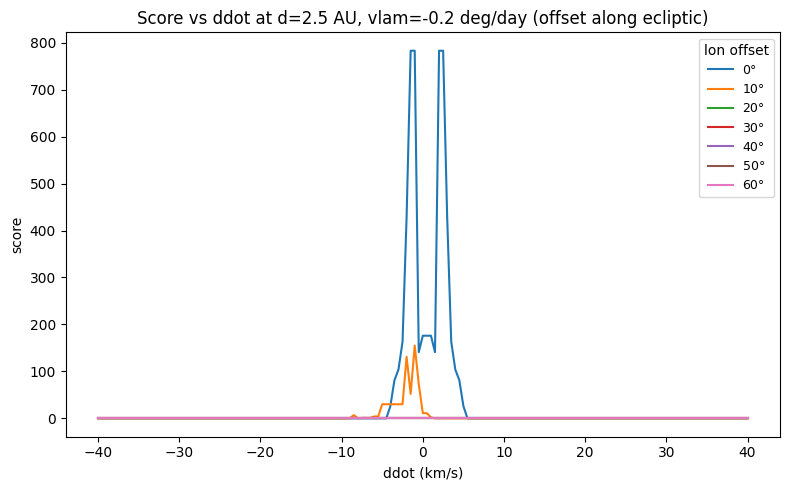

In [67]:
def score_vs_ddot_for_offset(longitudeOffset_deg,
                             obstime_str,
                             d_test=2.5,
                             vlam_test=-0.2,
                             vbeta_test=0.0,
                             ddot_grid=np.linspace(-40, 40, 161),
                             verbose=False):
    # anti-sun at this time
    raAS_deg, decAS_deg = anti_sun_radec_icrs(obstime_str)

    # apply longitude offset along ecliptic
    ra0_deg, dec0_deg = getECLposition(raAS_deg, decAS_deg, obstime_str, longitudeOffset_deg)

    # convert vlam,vbeta to RA/Dec rates 
    dra_test, ddec_test = nsc.ecliptic_rates_to_radec_rates1(
        ra0_deg, dec0_deg, vlam_test, vbeta_test, obstime_str
    )

    scores = []
    for dd in ddot_grid:
        out = scorer_mba_s3m.compute_score(
            obstime_str=obstime_str,
            ra_deg=ra0_deg,
            dec_deg=dec0_deg,
            dra_deg_per_day=dra_test,
            ddec_deg_per_day=ddec_test,
            mag=mag,
            d_au=d_test,
            ddot_kms=dd
        )
        scores.append(out["score"])

    scores = np.array(scores)

    if verbose:
        imax = np.argmax(scores)
        print(f"offset={longitudeOffset_deg:5.1f} deg  "
              f"peak={scores[imax]:.3g} at ddot={ddot_grid[imax]:.2f} km/s  "
              f"score(ddot=0)={scores[np.argmin(np.abs(ddot_grid-0.0))]:.3g}  "
              f"ra,dec={ra0_deg:.3f},{dec0_deg:.3f}")

    return ddot_grid, scores

# run offsets from 0 to 60 deg 
offsets = np.arange(0, 61, 10)  # 0,10,20,...,60
ddot_grid = np.linspace(-40, 40, 161)

plt.figure(figsize=(8,5))
for off in offsets:
    x, y = score_vs_ddot_for_offset(off, obstime_str, ddot_grid=ddot_grid, verbose=True)
    plt.plot(x, y, label=f"{off}°")

plt.xlabel("ddot (km/s)")
plt.ylabel("score")
#plt.ylim(0,100)
plt.title(f"Score vs ddot at d=2.5 AU, vlam=-0.2 deg/day (offset along ecliptic)")
plt.legend(title="lon offset", fontsize=9)
plt.tight_layout()
plt.show()


In [68]:
# Sun GM in km^3/s^2 
MU_SUN_KM3_S2 = 1.32712440018e11
mu_sun = 1.32712440018e11
AU_KM = 149_597_870.7


In [69]:

def trace_chain(scorer, obstime_str, ra_deg, dec_deg, dra_deg_day, ddec_deg_day, mag, d_au, ddot_kms,
                mu_sun_km3_s2=MU_SUN_KM3_S2):
 
    # sky unit vectors
    l_hat, v_hat = scorer._compute_unit_vectors(ra_deg, dec_deg, dra_deg_day, ddec_deg_day)

    # Earth + observer
    obstime, rE, vE, r_tele = scorer._get_earth_and_observer(obstime_str)

    # geocentric state from observables
    r_geo, v_geo = scorer._observables_to_geocentric_state(l_hat, v_hat, d_au, ddot_kms)

    # heliocentric equatorial
    r_helio, v_helio = scorer._geo_to_helio(r_geo, v_geo, rE, vE, r_tele)

    # heliocentric ecliptic
    r_ecl, v_ecl = scorer._equatorial_to_ecliptic(r_helio, v_helio)

    # specific orbital energy and a 
    r_km = np.linalg.norm(r_ecl, axis=-1)[0]
    v_kms = np.linalg.norm(v_ecl, axis=-1)[0]
    eps = 0.5 * v_kms**2 - mu_sun_km3_s2 / r_km                 # km^2/s^2
    a_energy_km = -mu_sun_km3_s2 / (2.0 * eps) if eps != 0 else np.inf
    a_energy_AU = a_energy_km / AU_KM

    # ADAM keplerian + H + weight
    a_adam, e_adam, i_adam = scorer._to_keplerian_adam(r_ecl, v_ecl, obstime)
    H0 = scorer._compute_h0_from_distance(r_helio, r_geo, r_tele, d_au, mag)
    w = scorer._score_from_elements(a_adam, e_adam, H0, i_adam)

    out = {
        "r_km": r_km, "v_kms": v_kms,
        "eps_km2_s2": eps, "a_energy_AU": a_energy_AU,
        "a_adam_AU": a_adam, "e_adam": e_adam, "i_adam_deg": i_adam,
        "H": H0, "w": w,
        "r_geo": r_geo, "v_geo": v_geo, "r_helio": r_helio, "v_helio": v_helio,
        "r_ecl": r_ecl, "v_ecl": v_ecl
    }
    return out


In [70]:
for dd in [-40, -20, -10, 0, 10, 20, 40]:
    tr = trace_chain(
        scorer_mba_s3m, obstime_str,
        ra0_deg, dec0_deg, dra_test, ddec_test, mag,
        d_test, dd
    )
    print(
        f"ddot={dd:6.1f}  eps={tr['eps_km2_s2']:+.3e}  a_energy={tr['a_energy_AU']:+.3f}  "
        f"a_adam={tr['a_adam_AU']:+.3f}  e={tr['e_adam']:.3f}  i={tr['i_adam_deg']:.3f}  "
        f"H={tr['H']:.3f}  w={tr['w']:.3e}"
    )


ddot= -40.0  eps=+6.719e+02  a_energy=-0.660  a_adam=-0.660  e=2.325  i=0.003  H=19.257  w=0.000e+00
ddot= -20.0  eps=+6.237e+01  a_energy=-7.112  a_adam=-7.112  e=1.188  i=0.002  H=19.257  w=0.000e+00
ddot= -10.0  eps=-9.238e+01  a_energy=+4.801  a_adam=+4.801  e=0.625  i=0.003  H=19.257  w=0.000e+00
ddot=   0.0  eps=-1.471e+02  a_energy=+3.015  a_adam=+3.015  e=0.164  i=0.004  H=19.257  w=1.760e+02
ddot=  10.0  eps=-1.019e+02  a_energy=+4.353  a_adam=+4.353  e=0.570  i=0.006  H=19.257  w=0.000e+00
ddot=  20.0  eps=+4.336e+01  a_energy=-10.231  a_adam=-10.231  e=1.135  i=0.007  H=19.257  w=0.000e+00
ddot=  40.0  eps=+6.338e+02  a_energy=-0.700  a_adam=-0.700  e=2.286  i=0.010  H=19.257  w=0.000e+00


Expected a (AU): 2.5
Recovered a (AU): min/max = 2.4999999995614686 2.49999999956147
Recovered e: min/max = 1.7541221932757039e-10 1.7541265272129883e-10
Recovered i (deg): min/max = 0.0 0.0


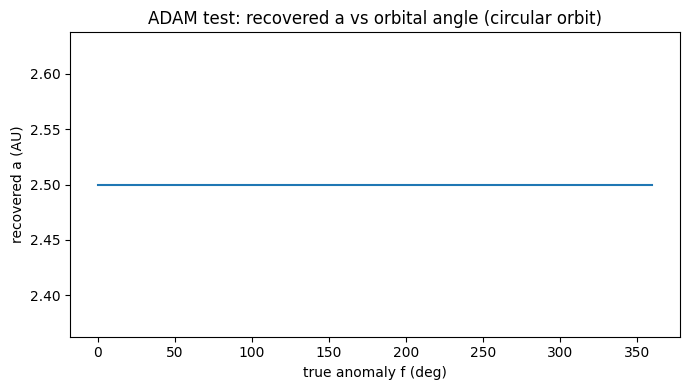

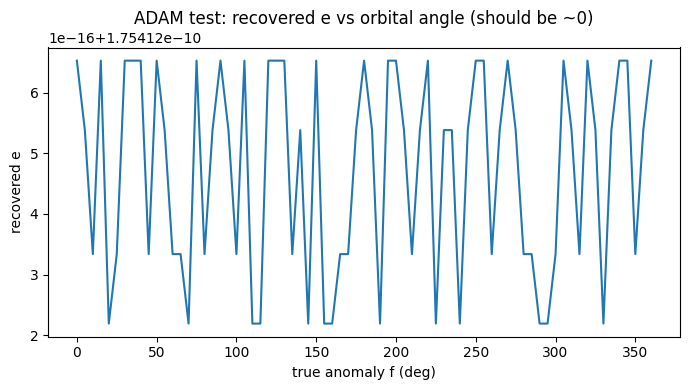

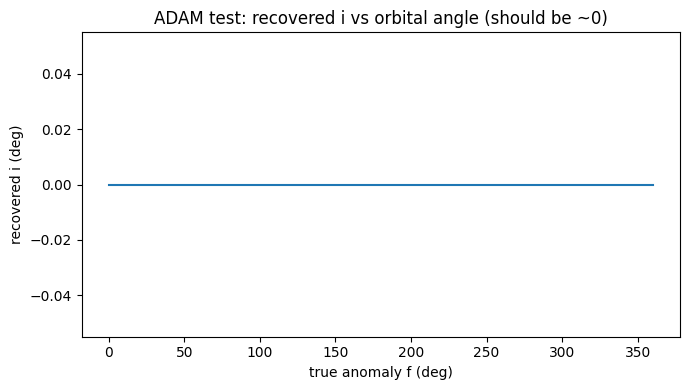

In [71]:
AU_km = 149_597_870.7
mu_sun = 1.32712440018e11  # km^3/s^2

# Choosing a circular orbit
a_AU = 2.5
a_km = a_AU * AU_km
v_circ = np.sqrt(mu_sun / a_km)  # km/s

obstime = Time("2025-09-23T00:00:00")

# True anomaly around the orbit
f_deg = np.linspace(0, 360, 73)  # every 5 deg
f = np.deg2rad(f_deg)

# Heliocentric ecliptic Cartesian state for a circular orbit in xy-plane
# r = a [cos f, sin f, 0]
# v = v_circ [-sin f, cos f, 0]
r_ecl = np.column_stack([a_km*np.cos(f), a_km*np.sin(f), np.zeros_like(f)])
v_ecl = np.column_stack([-v_circ*np.sin(f), v_circ*np.cos(f), np.zeros_like(f)])

# Calling ADAM
a_rec = []
e_rec = []
i_rec = []

for rr, vv in zip(r_ecl, v_ecl):
    a_val, e_val, i_val = scorer_mba_s3m._to_keplerian_adam(rr, vv, obstime)
    a_rec.append(a_val)
    e_rec.append(e_val)
    i_rec.append(i_val)

a_rec = np.array(a_rec)
e_rec = np.array(e_rec)
i_rec = np.array(i_rec)

print("Expected a (AU):", a_AU)
print("Recovered a (AU): min/max =", a_rec.min(), a_rec.max())
print("Recovered e: min/max =", e_rec.min(), e_rec.max())
print("Recovered i (deg): min/max =", i_rec.min(), i_rec.max())

plt.figure(figsize=(7,4))
plt.plot(f_deg, a_rec)
plt.xlabel("true anomaly f (deg)")
plt.ylabel("recovered a (AU)")
plt.title("ADAM test: recovered a vs orbital angle (circular orbit)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
plt.plot(f_deg, e_rec)
plt.xlabel("true anomaly f (deg)")
plt.ylabel("recovered e")
plt.title("ADAM test: recovered e vs orbital angle (should be ~0)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
plt.plot(f_deg, i_rec)
plt.xlabel("true anomaly f (deg)")
plt.ylabel("recovered i (deg)")
plt.title("ADAM test: recovered i vs orbital angle (should be ~0)")
plt.tight_layout()
plt.show()


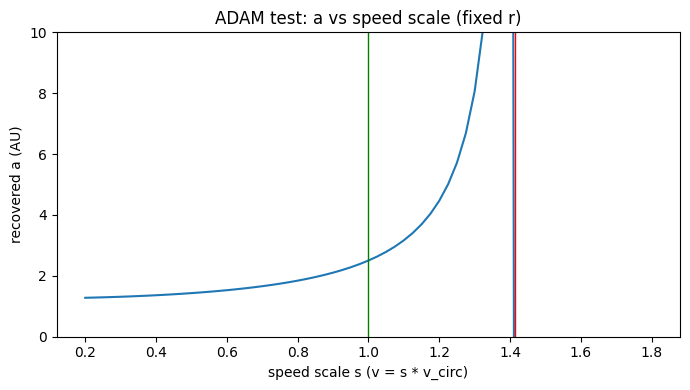

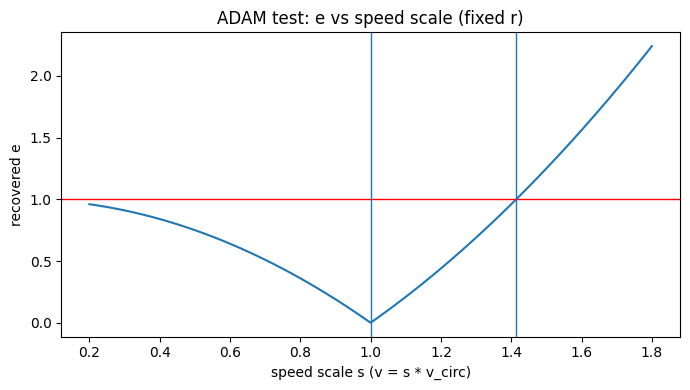

v_circ = 18.837 km/s, v_esc = 26.640 km/s


In [72]:
AU_km = 149_597_870.7
mu_sun = 1.32712440018e11  # km^3/s^2

a_AU = 2.5
a_km = a_AU * AU_km
v_circ = np.sqrt(mu_sun / a_km)
v_esc = np.sqrt(2) * v_circ

obstime = Time("2025-09-23T00:00:00")

# Pick a point on the orbit (so f=0): r=[a,0,0]
r0 = np.array([a_km, 0.0, 0.0])

# Tangential direction at f=0 is +y
vhat_tan = np.array([0.0, 1.0, 0.0])

scales = np.linspace(0.2, 1.8, 65)  # multiply v_circ
a_list, e_list, i_list = [], [], []

for s in scales:
    v0 = (s * v_circ) * vhat_tan
    a_val, e_val, i_val = scorer_mba_s3m._to_keplerian_adam(r0, v0, obstime)
    a_list.append(a_val)
    e_list.append(e_val)
    i_list.append(i_val)

a_list = np.array(a_list)
e_list = np.array(e_list)

plt.figure(figsize=(7,4))
plt.plot(scales, a_list)
plt.axvline(1.0, lw=1, color = "green")                 # circular
plt.axvline(np.sqrt(2), lw=1, color = "red")          # escape
plt.xlabel("speed scale s (v = s * v_circ)")
plt.ylabel("recovered a (AU)")
plt.title("ADAM test: a vs speed scale (fixed r)")
plt.ylim(0,10)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
plt.plot(scales, e_list)
plt.axhline(1.0, lw=1, color = "red")                 # hyperbolic threshold
plt.axvline(1.0, lw=1)
plt.axvline(np.sqrt(2), lw=1)
plt.xlabel("speed scale s (v = s * v_circ)")
plt.ylabel("recovered e")
plt.title("ADAM test: e vs speed scale (fixed r)")
plt.tight_layout()
plt.show()

print(f"v_circ = {v_circ:.3f} km/s, v_esc = {v_esc:.3f} km/s")


In [73]:
print("W stats:", "min", W.min(), "max", W.max(), "num>0", np.count_nonzero(W > 0), "of", W.size)


W stats: min 0.0 max 6248.0 num>0 378 of 14460


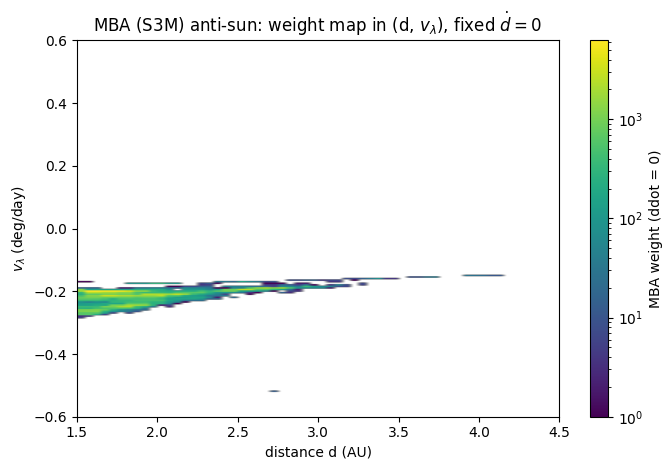

In [74]:
import matplotlib.colors as colors

W_plot = W.T.copy()

# For log scale: replace non-positive values with NaN so they don't break norm = Log for imshow
W_plot[W_plot <= 0] = np.nan

vmin = np.nanmin(W_plot)
vmax = np.nanmax(W_plot)

plt.figure(figsize=(7, 4.8))

if np.isfinite(vmin) and np.isfinite(vmax) and (vmax > vmin):
    im = plt.imshow(
        W_plot,
        origin="lower",
        aspect="auto",
        extent=[d_grid[0], d_grid[-1], vlam_grid[0], vlam_grid[-1]],
        norm=colors.LogNorm(vmin=vmin, vmax=vmax),
    )
    plt.colorbar(im, label="MBA weight (ddot = 0)")
else:
    # uses linear scale
    im = plt.imshow(
        np.nan_to_num(W_plot, nan=0.0),
        origin="lower",
        aspect="auto",
        extent=[d_grid[0], d_grid[-1], vlam_grid[0], vlam_grid[-1]],
    )
    plt.colorbar(im, label="MBA weight (ddot = 0) [linear]")

plt.xlabel("distance d (AU)")
plt.ylabel(r"$v_\lambda$ (deg/day)")
plt.title(r"MBA (S3M) anti-sun: weight map in (d, $v_\lambda$), fixed $\dot d = 0$")
plt.tight_layout()
plt.show()


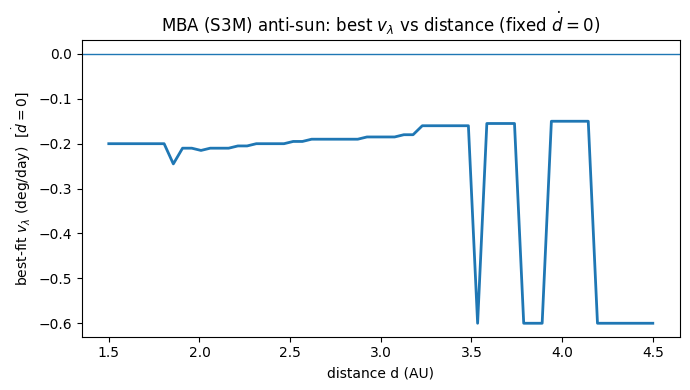

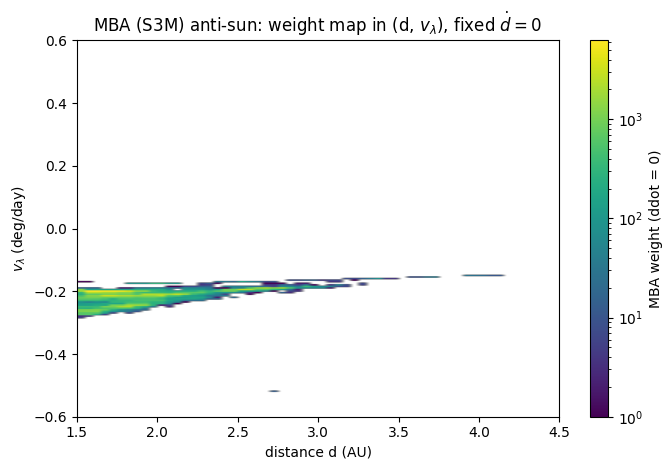

Peak weights: min=0.000e+00, max=6.248e+03


In [75]:
plt.figure(figsize=(7, 4))
plt.plot(d_grid, best_vlam, lw=2)
plt.axhline(0.0, lw=1)
plt.xlabel("distance d (AU)")
plt.ylabel(r"best-fit $v_\lambda$ (deg/day)  [$\dot d = 0$]")
plt.title("MBA (S3M) anti-sun: best $v_\\lambda$ vs distance (fixed $\dot d=0$)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4.8))
plt.imshow(
    W.T,
    origin="lower",
    aspect="auto",
    extent=[d_grid[0], d_grid[-1], vlam_grid[0], vlam_grid[-1]],
    norm = "log"
)
plt.colorbar(label="MBA weight (ddot = 0)")
plt.xlabel("distance d (AU)")
plt.ylabel(r"$v_\lambda$ (deg/day)")
plt.title("MBA (S3M) anti-sun: weight map in (d, $v_\\lambda$), fixed $\dot d=0$")
plt.tight_layout()
plt.show()

print(f"Peak weights: min={best_w.min():.3e}, max={best_w.max():.3e}")


Extracting elements on ridge: 100%|██████████| 49/49 [00:00<00:00, 96.41d/s]


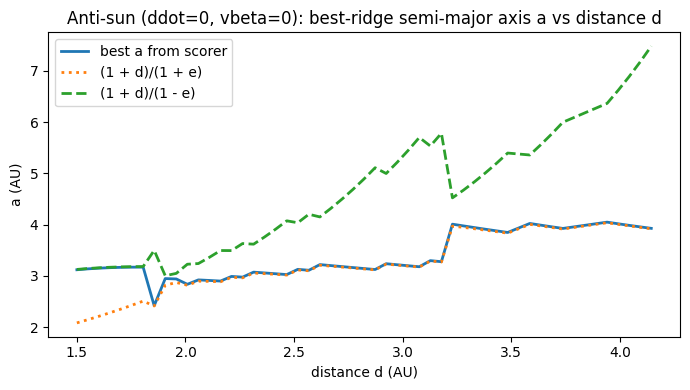

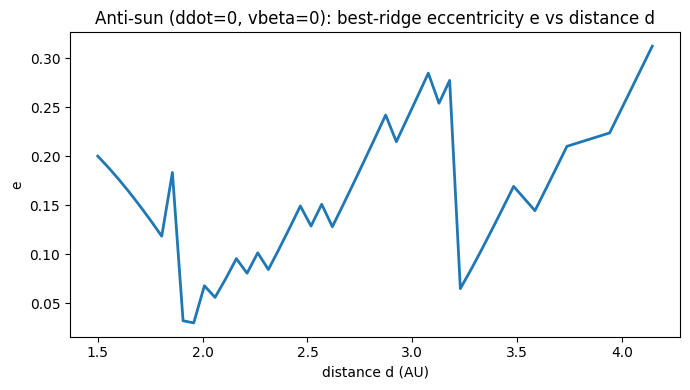

a range: 2.41835842415191 to 4.0486507255779465
e range: 0.0299403266473735 to 0.312548239974511
i range: 0.0039517998526891205 to 0.005324278746760472
H range: 17.330055151554554 to 21.088581179403448


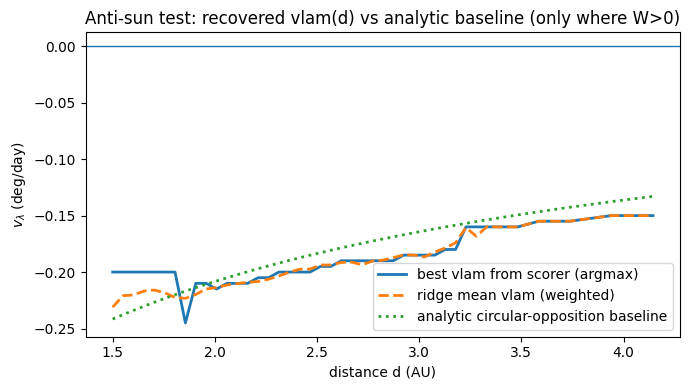

Supported d range: 1.5 to 4.1440677966101696
How many supported points: 49 / 60


In [76]:
# mask unsupported distances 
row_max = W.max(axis=1)
mask = row_max > 0

#for opposition, circular coplanar orbit
vE = 0.986  # deg/day
d = d_grid.copy()
R = 1.0 + d
vlam_pred = vE * (1/np.sqrt(R) - 1.0) / d  # deg/day, negative, |vlam| decreases with d

# using "center of mass" of the ridge instead of argmax
# this avoids bin/edge effects if the ridge is broad
Wpos = W.copy()
Wpos[Wpos < 0] = 0 # negative weight clipped to 0
vlam_mean = np.full(len(d_grid), np.nan)
for k in range(len(d_grid)):
    s = Wpos[k].sum()
    if s > 0:
        vlam_mean[k] = np.sum(vlam_grid * Wpos[k]) / s

#  Extract orbital elements (a,e,i,H) along the best-vlam ridge vs distance 

a_best = np.full(len(d_grid), np.nan)
e_best = np.full(len(d_grid), np.nan)
i_best = np.full(len(d_grid), np.nan)
H_best = np.full(len(d_grid), np.nan)
score_best = np.full(len(d_grid), np.nan)

for k in tqdm(np.where(mask)[0], desc="Extracting elements on ridge", unit="d"):
    d_au = d_grid[k]
    vlam = best_vlam[k]

    # convert (vlam, vbeta_fixed) -> (dra, ddec) at the anti-sun sky position
    dra, ddec = nsc.ecliptic_rates_to_radec_rates1(
        ra0_deg, dec0_deg, vlam, vbeta_fixed, obstime_str
    )

    out = scorer_mba_s3m.compute_score(
        obstime_str=obstime_str,
        ra_deg=ra0_deg,
        dec_deg=dec0_deg,
        dra_deg_per_day=dra,
        ddec_deg_per_day=ddec,
        mag=mag,
        d_au=d_au,
        ddot_kms=ddot_fixed
    )

    score_best[k] = out["score"]
    a_best[k] = out["a"]
    e_best[k] = out["e"]
    i_best[k] = out["i"]
    H_best[k] = out["H"]

# Plot a vs d (only where supported)
plt.figure(figsize=(7,4))

# main curve
plt.plot(d_grid[mask], a_best[mask], lw=2, label="best a from scorer")

# plots the upper and lower range
plt.plot(d_grid[mask], (1 + d_grid[mask])/(1 + e_best[mask]),
         ls=":", lw=2, label="(1 + d)/(1 + e)")
plt.plot(d_grid[mask], (1 + d_grid[mask])/(1 - e_best[mask]),
         ls="--", lw=2, label="(1 + d)/(1 - e)")


#plt.plot(d_grid[mask], a_best[mask], lw=2)
plt.xlabel("distance d (AU)")
plt.ylabel("a (AU)")
plt.title("Anti-sun (ddot=0, vbeta=0): best-ridge semi-major axis a vs distance d")
plt.tight_layout()
plt.legend()
plt.show()

# plotting e vs d
plt.figure(figsize=(7,4))
plt.plot(d_grid[mask], e_best[mask], lw=2)
plt.xlabel("distance d (AU)")
plt.ylabel("e")
plt.title("Anti-sun (ddot=0, vbeta=0): best-ridge eccentricity e vs distance d")
plt.tight_layout()
plt.show()



print("a range:", np.nanmin(a_best), "to", np.nanmax(a_best))
print("e range:", np.nanmin(e_best), "to", np.nanmax(e_best))
print("i range:", np.nanmin(i_best), "to", np.nanmax(i_best))
print("H range:", np.nanmin(H_best), "to", np.nanmax(H_best))


# plot comparison only where supported aka no zero
plt.figure(figsize=(7,4))
plt.plot(d_grid[mask], best_vlam[mask], lw=2, label="best vlam from scorer (argmax)")
plt.plot(d_grid[mask], vlam_mean[mask], lw=2, ls="--", label="ridge mean vlam (weighted)")
plt.plot(d_grid[mask], vlam_pred[mask], lw=2, ls=":", label="analytic circular-opposition baseline")

plt.axhline(0, lw=1)
plt.xlabel("distance d (AU)")
plt.ylabel(r"$v_\lambda$ (deg/day)")
plt.title("Anti-sun test: recovered vlam(d) vs analytic baseline (only where W>0)")
plt.legend()
plt.tight_layout()
plt.show()

print("Supported d range:", d_grid[mask].min(), "to", d_grid[mask].max())
print("How many supported points:", mask.sum(), "/", len(mask))


In [97]:
from astropy.coordinates import get_body_barycentric_posvel, solar_system_ephemeris

t = Time(obstime_str, scale="tdb")
with solar_system_ephemeris.set("de432s"):
    rE_bary, vE_bary = get_body_barycentric_posvel("earth", t)

rE = np.array([rE_bary.x.to_value(u.AU),
               rE_bary.y.to_value(u.AU),
               rE_bary.z.to_value(u.AU)], float)

vE = np.array([vE_bary.x.to_value(u.AU/u.day),
               vE_bary.y.to_value(u.AU/u.day),
               vE_bary.z.to_value(u.AU/u.day)], float)


In [98]:
print(type(rE), np.shape(rE))
print(type(vE), np.shape(vE))


<class 'numpy.ndarray'> (3,)
<class 'numpy.ndarray'> (3,)


In [100]:
print("r_eq in globals?", "r_eq" in globals())
if "r_eq" in globals():
    print("r_eq:", type(r_eq), getattr(r_eq, "shape", None))



r_eq in globals? True
r_eq: <class 'numpy.ndarray'> (13883361, 3)


In [99]:
r_rel = r_eq - rE[None, :]
v_rel = v_eq - vE[None, :]


After good-mask: 13883361 objects
After anti-sun sep < 30.0° filter: 1157026 objects


RA/Dec rates → ecliptic rates: 100%|██████████| 6/6 [00:00<00:00, 10.32it/s]


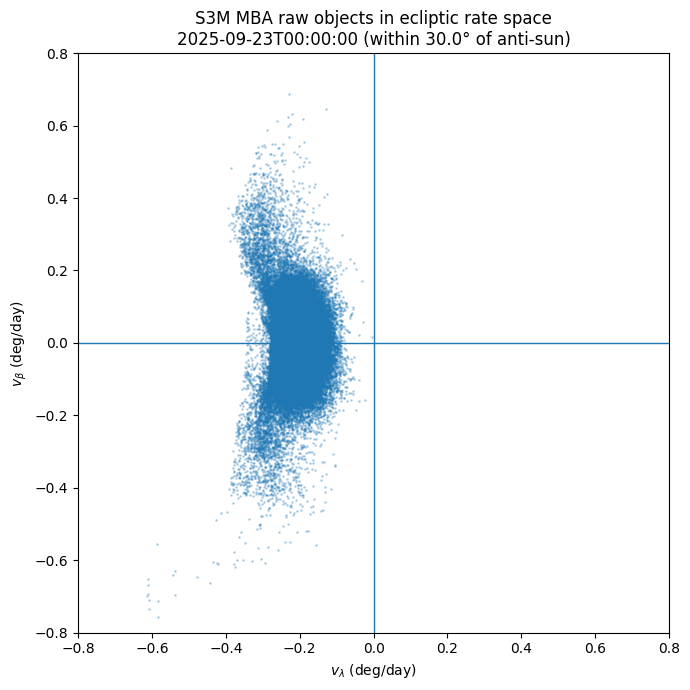

In [94]:
# ============================================================
# CELL: FULL “raw S3M MBAs in (v_lambda, v_beta)” segment (anti-sun)
#
# Uses: your radec_rates_to_ecliptic_rates_at_obstime()
# Assumes you already computed:
#   r_rel, v_rel        : (N,3) arrays in AU and AU/day in EQUATORIAL frame
#   anti_ra_deg, anti_dec_deg
#   obstime_str
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import astropy.units as u
from astropy.time import Time
from astropy.coordinates import SkyCoord, GCRS

# -----------------------------
# 1) Convert relative Cartesian (r_rel, v_rel) -> RA/Dec + RA/Dec rates
# -----------------------------
x, y, z     = r_rel[:, 0], r_rel[:, 1], r_rel[:, 2]
vx, vy, vz  = v_rel[:, 0], v_rel[:, 1], v_rel[:, 2]

rho2 = x * x + y * y          # projected distance^2
r2   = rho2 + z * z           # |r|^2
rho  = np.sqrt(rho2)

# RA, Dec (radians)
ra  = np.arctan2(y, x)
dec = np.arctan2(z, rho)

# Rates (radians/day)
dra  = (x * vy - y * vx) / rho2
ddec = (vz * rho2 - z * (x * vx + y * vy)) / (r2 * rho)

good = (
    np.isfinite(ra) & np.isfinite(dec) &
    np.isfinite(dra) & np.isfinite(ddec) &
    (rho2 > 0) & np.isfinite(r2) & (r2 > 0)
)

ra_deg       = (np.rad2deg(ra[good]) % 360.0)
dec_deg      = np.rad2deg(dec[good])
dra_deg_day  = np.rad2deg(dra[good])
ddec_deg_day = np.rad2deg(ddec[good])

print("After good-mask:", len(ra_deg), "objects")

# -----------------------------
# 2) OPTIONAL: restrict to a cone around anti-sun (recommended)
# -----------------------------
max_sep_deg = 30.0  # set to None if you want ALL objects (no anti-sun filter)

if max_sep_deg is not None:
    t_obs = Time(obstime_str)
    sc = SkyCoord(ra=ra_deg * u.deg, dec=dec_deg * u.deg, frame=GCRS(obstime=t_obs))
    anti_sc = SkyCoord(
        ra=anti_ra_deg * u.deg,
        dec=anti_dec_deg * u.deg,
        frame=GCRS(obstime=t_obs),
    )
    sep = sc.separation(anti_sc).deg
    m = sep <= max_sep_deg

    ra_deg, dec_deg = ra_deg[m], dec_deg[m]
    dra_deg_day, ddec_deg_day = dra_deg_day[m], ddec_deg_day[m]

    print(f"After anti-sun sep < {max_sep_deg}° filter:", len(ra_deg), "objects")

# -----------------------------
# 3) Convert RA/Dec rates -> ecliptic rates (your function), chunked
# -----------------------------
vlam  = np.empty_like(dra_deg_day, dtype=float)
vbeta = np.empty_like(dra_deg_day, dtype=float)

chunk = 200_000
for k0 in tqdm(range(0, len(dra_deg_day), chunk), desc="RA/Dec rates → ecliptic rates"):
    k1 = min(k0 + chunk, len(dra_deg_day))
    vlam[k0:k1], vbeta[k0:k1] = radec_rates_to_ecliptic_rates_at_obstime(
        ra_deg[k0:k1], dec_deg[k0:k1],
        dra_deg_day[k0:k1], ddec_deg_day[k0:k1],
        obstime_str
    )

# -----------------------------
# 4) Plot (downsample for display)
# -----------------------------
Nplot = 300_000
if len(vlam) > Nplot:
    idx = np.random.choice(len(vlam), Nplot, replace=False)
    vlam_p, vbeta_p = vlam[idx], vbeta[idx]
else:
    vlam_p, vbeta_p = vlam, vbeta

plt.figure(figsize=(7, 7))
plt.scatter(vlam_p, vbeta_p, s=1, alpha=0.25)
plt.axhline(0, lw=1)
plt.axvline(0, lw=1)
plt.xlabel(r"$v_\lambda$ (deg/day)")
plt.ylabel(r"$v_\beta$ (deg/day)")

ttl = f"S3M MBA raw objects in ecliptic rate space\n{obstime_str}"
if max_sep_deg is not None:
    ttl += f" (within {max_sep_deg}° of anti-sun)"
plt.title(ttl)

plt.xlim(-0.8, 0.8)
plt.ylim(-0.8, 0.8)
plt.tight_layout()
plt.show()



In [102]:
# 1) confirm it exists
print("r_rel in globals?", "r_rel" in globals())
print("v_rel in globals?", "v_rel" in globals())

# 2) what are they?
if "r_rel" in globals(): 
    print("r_rel:", type(r_rel), getattr(r_rel, "shape", None))
if "v_rel" in globals(): 
    print("v_rel:", type(v_rel), getattr(v_rel, "shape", None))

# 3) search input history for where it was created
import re
for i, s in enumerate(In):
    if re.search(r"\br_rel\s*=", s) or re.search(r"\bv_rel\s*=", s):
        print(f"\n--- likely definition in In[{i}] ---\n{s}")


r_rel in globals? True
v_rel in globals? True
r_rel: <class 'numpy.ndarray'> (13883361, 3)
v_rel: <class 'numpy.ndarray'> (13883361, 3)

--- likely definition in In[29] ---
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import astropy.units as u
from astropy.time import Time
from astropy.coordinates import SkyCoord, get_sun, GCRS, GeocentricTrueEcliptic
from astropy.coordinates.representation import CartesianRepresentation, CartesianDifferential

# -----------------------------
# Config
# -----------------------------
obstime_str = "2025-09-23T00:00:00"
t = Time(obstime_str, scale="tdb")

# "anti-sun direction" (geocentric-of-date-ish; good enough for this diagnostic)
sun_gcrs = get_sun(t).transform_to(GCRS(obstime=t))
anti = SkyCoord(
    x=-sun_gcrs.cartesian.x, y=-sun_gcrs.cartesian.y, z=-sun_gcrs.cartesian.z,
    representation_type="cartesian",
    frame=GCRS(obstime=t),
)
anti_ra_deg  = anti.spherical.lon.to_value(u.deg)
anti_dec_deg = anti.spherical.la

After good-mask: 13883361 objects
After anti-sun sep<1.0 deg filter: 2375 objects


RA/Dec rates → ecliptic rates: 100%|██████████| 1/1 [00:00<00:00, 134.57it/s]


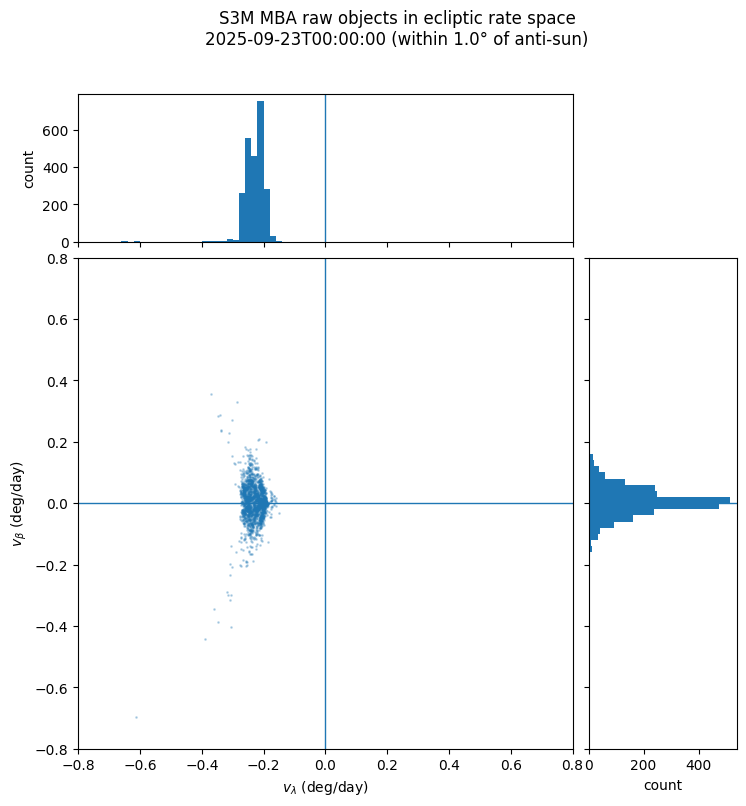

In [79]:
# Convert relative Cartesian (r_rel, v_rel) -> RA/Dec + RA/Dec rates

x, y, z   = r_rel[:, 0], r_rel[:, 1], r_rel[:, 2]
vx, vy, vz = v_rel[:, 0], v_rel[:, 1], v_rel[:, 2]

rho2 = x*x + y*y                 # projected distance^2
r2   = rho2 + z*z                # |r|^2
rho  = np.sqrt(rho2)
r    = np.sqrt(r2)

# RA, Dec (radians)
ra  = np.arctan2(y, x)
dec = np.arctan2(z, rho)

# Rates (radians/day)
# dRA/dt
dra = (x*vy - y*vx) / rho2

# dDec/dt
ddec = (vz * rho2 - z * (x*vx + y*vy)) / (r2 * rho)

# mask
good = np.isfinite(ra) & np.isfinite(dec) & np.isfinite(dra) & np.isfinite(ddec) & (rho2 > 0) & np.isfinite(r2) & (r2 > 0)

ra_deg       = (np.rad2deg(ra[good]) % 360.0)
dec_deg      = np.rad2deg(dec[good])
dra_deg_day  = np.rad2deg(dra[good])
ddec_deg_day = np.rad2deg(ddec[good])

print("After good-mask:", len(ra_deg), "objects")


# Restrict to a certain degree around anti-sun 

max_sep_deg = 1.0   # set to None if you want ALL objects, not anti-sun field only
if max_sep_deg is not None:
    t_obs = Time(obstime_str)
    sc = SkyCoord(ra=ra_deg*u.deg, dec=dec_deg*u.deg, frame=GCRS(obstime=t_obs))
    anti_sc = SkyCoord(ra=anti_ra_deg*u.deg, dec=anti_dec_deg*u.deg, frame=GCRS(obstime=t_obs))
    sep = sc.separation(anti_sc).deg
    m = sep <= max_sep_deg

    ra_deg, dec_deg = ra_deg[m], dec_deg[m]
    dra_deg_day, ddec_deg_day = dra_deg_day[m], ddec_deg_day[m]
    print(f"After anti-sun sep<{max_sep_deg} deg filter:", len(ra_deg), "objects")


# Convert RA/Dec rates -> ecliptic rates 

vlam  = np.empty_like(dra_deg_day, dtype=float)
vbeta = np.empty_like(dra_deg_day, dtype=float)

chunk = 200_000
for k0 in tqdm(range(0, len(dra_deg_day), chunk), desc="RA/Dec rates → ecliptic rates"):
    k1 = min(k0 + chunk, len(dra_deg_day))
    vlam[k0:k1], vbeta[k0:k1] = radec_rates_to_ecliptic_rates_at_obstime(
        ra_deg[k0:k1], dec_deg[k0:k1],
        dra_deg_day[k0:k1], ddec_deg_day[k0:k1],
        obstime_str
    )



Nplot = 300_000
if len(vlam) > Nplot:
    idx = np.random.choice(len(vlam), Nplot, replace=False)
    vlam_p, vbeta_p = vlam[idx], vbeta[idx]
else:
    vlam_p, vbeta_p = vlam, vbeta


# scatter + marginal histograms 

xlim = (-0.8, 0.8)
ylim = (-0.8, 0.8)
bins = 80

fig = plt.figure(figsize=(8.5, 8.5))
gs = fig.add_gridspec(
    nrows=2, ncols=2,
    width_ratios=[4.0, 1.2],
    height_ratios=[1.2, 4.0],
    wspace=0.05, hspace=0.05
)

ax_histx = fig.add_subplot(gs[0, 0])
ax_scatt = fig.add_subplot(gs[1, 0], sharex=ax_histx)
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax_scatt)

# Scatter
ax_scatt.scatter(vlam_p, vbeta_p, s=1, alpha=0.25)
ax_scatt.axhline(0, lw=1)
ax_scatt.axvline(0, lw=1)
ax_scatt.set_xlabel(r"$v_\lambda$ (deg/day)")
ax_scatt.set_ylabel(r"$v_\beta$ (deg/day)")
ax_scatt.set_xlim(*xlim)
ax_scatt.set_ylim(*ylim)

# Top histogram (v_lambda)
ax_histx.hist(vlam_p, bins=bins, range=xlim)
ax_histx.axvline(0, lw=1)
ax_histx.tick_params(axis="x", labelbottom=False)
ax_histx.set_ylabel("count")

# Right histogram (v_beta)
ax_histy.hist(vbeta_p, bins=bins, range=ylim, orientation="horizontal")
ax_histy.axhline(0, lw=1)
ax_histy.tick_params(axis="y", labelleft=False)
ax_histy.set_xlabel("count")

# Title
ttl = f"S3M MBA raw objects in ecliptic rate space\n{obstime_str}"
if max_sep_deg is not None:
    ttl += f" (within {max_sep_deg}° of anti-sun)"
fig.suptitle(ttl, y=0.98)

plt.show()

In [80]:
# Build heliocentric and geocentric vectors in the same frame
# heliocentric vector of asteroid (Sun->object):
r_helio_vec = r_eq                      # (N,3) AU

# geocentric vector (Earth->object):
r_geo_vec = r_eq - rE[None, :]          # (N,3) AU

# Pull H from the df 
H_all = mba["H"].to_numpy(dtype=float)

# Apply the same masks as vlam/vbeta/ra/dec used
H_use = H_all[good]
r_helio_use = r_helio_vec[good]
r_geo_use   = r_geo_vec[good]

if "m" in globals():
    H_use = H_use[m]
    r_helio_use = r_helio_use[m]
    r_geo_use   = r_geo_use[m]

# Distances
r_sun = np.linalg.norm(r_helio_use, axis=1)   # AU
Delta = np.linalg.norm(r_geo_use, axis=1)     # AU

# Phase angle alpha at the object
# object->Sun = -r_helio, object->Earth = -r_geo
u_sun = -r_helio_use
u_earth = -r_geo_use
u_sun /= np.linalg.norm(u_sun, axis=1, keepdims=True)
u_earth /= np.linalg.norm(u_earth, axis=1, keepdims=True)

cos_alpha = np.sum(u_sun * u_earth, axis=1)
cos_alpha = np.clip(cos_alpha, -1.0, 1.0)
alpha = np.arccos(cos_alpha)

# HG phase function 
G = 0.15
A1, A2, B1, B2 = 3.33, 1.87, 0.63, 1.22
phi1 = np.exp(-A1 * np.tan(0.5 * alpha)**B1)
phi2 = np.exp(-A2 * np.tan(0.5 * alpha)**B2)
Phi = (1 - G) * phi1 + G * phi2

# Apparent magnitude
mag_app = H_use + 5.0*np.log10(r_sun * Delta) - 2.5*np.log10(Phi)

print("Defined mag_app:", len(mag_app))
print("mag_app stats (min/median/max):", np.nanmin(mag_app), np.nanmedian(mag_app), np.nanmax(mag_app))


Defined mag_app: 2375
mag_app stats (min/median/max): 16.155598300997408 24.091282043981654 29.830114277339735


mag<20.0: 88 objects


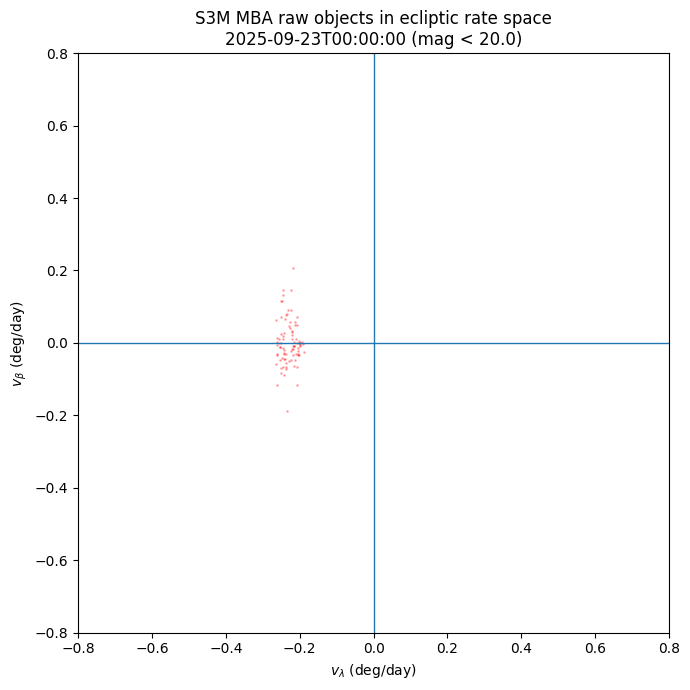

mag<24.0: 1121 objects


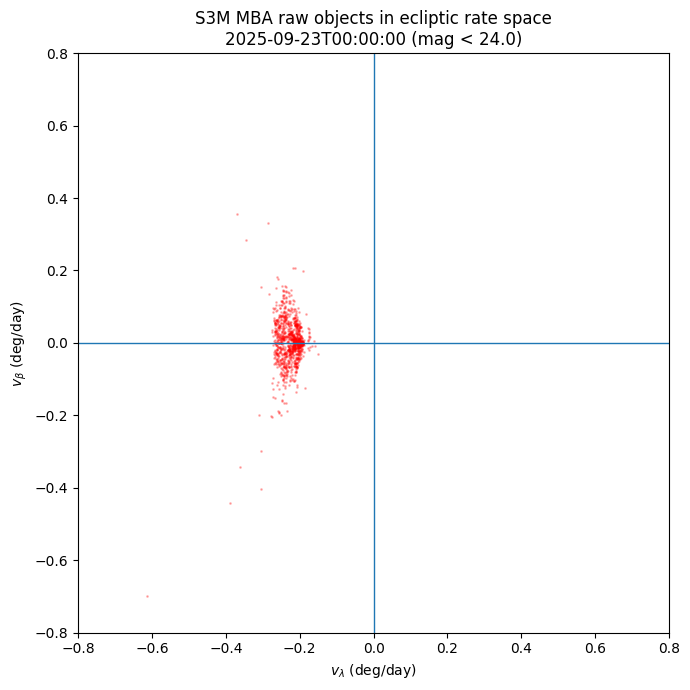

In [81]:
def plot_vlam_vbeta_magcut(vlam, vbeta, mag_app, cut, Nplot=300_000):
    sel = np.isfinite(vlam) & np.isfinite(vbeta) & np.isfinite(mag_app) & (mag_app < cut)
    vv1, vv2 = vlam[sel], vbeta[sel]
    print(f"mag<{cut}: {len(vv1)} objects")

    if len(vv1) > Nplot:
        idx = np.random.choice(len(vv1), Nplot, replace=False)
        vv1, vv2 = vv1[idx], vv2[idx]

    plt.figure(figsize=(7,7))
    plt.scatter(vv1, vv2, s=1, alpha=0.25, color = "red")
    plt.axhline(0, lw=1)
    plt.axvline(0, lw=1)
    plt.xlabel(r"$v_\lambda$ (deg/day)")
    plt.ylabel(r"$v_\beta$ (deg/day)")
    plt.title(f"S3M MBA raw objects in ecliptic rate space\n{obstime_str} (mag < {cut})")
    plt.xlim(-0.8, 0.8)
    plt.ylim(-0.8, 0.8)
    plt.tight_layout()
    plt.show()

plot_vlam_vbeta_magcut(vlam, vbeta, mag_app, cut=20.0)
plot_vlam_vbeta_magcut(vlam, vbeta, mag_app, cut=24.0)


After removing bad : 13883361 objects
After |Dec| < 1.25° cut: 548170 objects


Converting rates: 100%|██████████| 3/3 [00:00<00:00, 13.98it/s]


After lambda window: 375616 objects


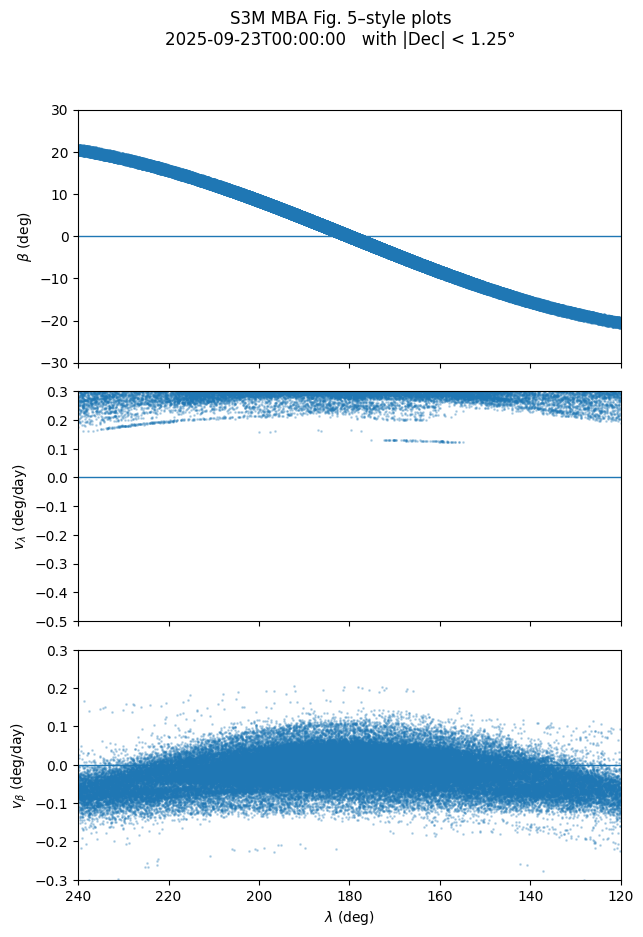

In [82]:
#   β vs λ
#   vλ vs λ
#   vβ vs λ
# Select |Dec| < 1.25 
#Convert relative Cartesian (r_rel, v_rel) → RA, Dec and their rates


x, y, z    = r_rel[:, 0], r_rel[:, 1], r_rel[:, 2]
vx, vy, vz = v_rel[:, 0], v_rel[:, 1], v_rel[:, 2]

rho2 = x*x + y*y  #squared distance from the z-axis
r2   = rho2 + z*z  #full squared distance
rho  = np.sqrt(rho2)  # xy-plane radius 

# Position
ra  = np.arctan2(y, x) # angle around the z-axis
dec = np.arctan2(z, rho) # elevation above the xy-plane

# Angular rates
dra  = (x*vy - y*vx) / rho2
ddec = (vz*rho2 - z*(x*vx + y*vy)) / (r2 * rho)

# Remove bad values
good = (
    np.isfinite(ra) & np.isfinite(dec) &
    np.isfinite(dra) & np.isfinite(ddec) &
    (rho2 > 0) & (r2 > 0)
)

ra_deg       = np.rad2deg(ra[good]) % 360.0
dec_deg      = np.rad2deg(dec[good])
dra_deg_day  = np.rad2deg(dra[good])
ddec_deg_day = np.rad2deg(ddec[good])

print("After removing bad :", len(ra_deg), "objects")

# Keep only objects near the celestial equator

dec_max = 1.25
#m = np.abs(dec_deg) < dec_max 
m = (dec_deg > -dec_max) & (dec_deg < dec_max)


ra_deg       = ra_deg[m]
dec_deg      = dec_deg[m]
dra_deg_day  = dra_deg_day[m]
ddec_deg_day = ddec_deg_day[m]

print(f"After |Dec| < {dec_max}° cut:", len(ra_deg), "objects")


# Convert RA/Dec → ecliptic longitude and latitude 


t_obs = Time(obstime_str)

sc  = SkyCoord(ra=ra_deg*u.deg, dec=dec_deg*u.deg,
               frame=GCRS(obstime=t_obs))
ecl = sc.transform_to(GeocentricTrueEcliptic(obstime=t_obs))

lam_deg  = ecl.lon.to_value(u.deg) % 360.0
beta_deg = ecl.lat.to_value(u.deg)

#Convert RA/Dec rates → ecliptic rates 


vlam  = np.empty_like(dra_deg_day)
vbeta = np.empty_like(dra_deg_day)

chunk = 200_000
for k0 in tqdm(range(0, len(dra_deg_day), chunk),
               desc="Converting rates"):
    k1 = min(k0 + chunk, len(dra_deg_day))
    vlam[k0:k1], vbeta[k0:k1] = radec_rates_to_ecliptic_rates_at_obstime(
        ra_deg[k0:k1], dec_deg[k0:k1],
        dra_deg_day[k0:k1], ddec_deg_day[k0:k1],
        obstime_str
    )

# Same x-axis window (120,240)

lam_lo, lam_hi = 120.0, 240.0
mlam = (lam_deg >= lam_lo) & (lam_deg <= lam_hi)

lam_deg  = lam_deg[mlam]
beta_deg = beta_deg[mlam]
vlam     = vlam[mlam]
vbeta    = vbeta[mlam]

print("After lambda window:", len(lam_deg), "objects")


Nplot = 300_000
if len(lam_deg) > Nplot:
    idx = np.random.choice(len(lam_deg), Nplot, replace=False)
    lam_p, beta_p = lam_deg[idx], beta_deg[idx]
    vlam_p, vbeta_p = vlam[idx], vbeta[idx]
else:
    lam_p, beta_p = lam_deg, beta_deg
    vlam_p, vbeta_p = vlam, vbeta



fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1, figsize=(7, 10), sharex=True,
    gridspec_kw=dict(height_ratios=[1.1, 1.0, 1.0], hspace=0.12)
)

# beta vs lambda
ax1.scatter(lam_p, beta_p, s=1, alpha=0.25)
ax1.axhline(0, lw=1)
ax1.set_ylabel(r"$\beta$ (deg)")
ax1.set_ylim(-30, 30)

# vlambda vs lambda
ax2.scatter(lam_p, vlam_p, s=1, alpha=0.25)
ax2.axhline(0, lw=1)
ax2.set_ylabel(r"$v_\lambda$ (deg/day)")
ax2.set_ylim(-0.5, 0.3)

# vbeta vs lambda
ax3.scatter(lam_p, vbeta_p, s=1, alpha=0.25)
ax3.axhline(0, lw=1)
ax3.set_ylabel(r"$v_\beta$ (deg/day)")
ax3.set_xlabel(r"$\lambda$ (deg)")
ax3.set_ylim(-0.3, 0.3)

# Reverse x-axis
ax3.set_xlim(240, 120)

fig.suptitle(f"S3M MBA Fig. 5–style plots\n{obstime_str}   with |Dec| < {dec_max}°")
plt.show()



In [83]:
near = np.abs(lam_deg - 180) < 10
print("median vlam near 180:", np.median(vlam[near]))
print("median vbeta near 180:", np.median(vbeta[near]))


median vlam near 180: 0.419097971812022
median vbeta near 180: -0.0009574232409703574


#### same plots but for ddot = -5

In [84]:
def anti_sun_radec_icrs(obstime_str):
    """Anti-sun RA/Dec in GCRS at obstime."""
    t = Time(obstime_str)
    sun = get_sun(t)
    cart = sun.cartesian
    anti = SkyCoord(
        x=-cart.x, y=-cart.y, z=-cart.z,
        representation_type="cartesian",
        frame="gcrs",
        obstime=t
    )
    return (
        anti.spherical.lon.to_value(u.deg),
        anti.spherical.lat.to_value(u.deg),
    )



ra0_deg, dec0_deg = anti_sun_radec_icrs(obstime_str)

print(f"obstime = {obstime_str}")
print(f"anti-sun RA,Dec (deg) = {ra0_deg:.6f}, {dec0_deg:.6f}")

# Grids

d_grid = np.linspace(1.5, 4.5, 60)          # AU
vlam_grid = np.linspace(-0.6, 0.6, 241)     # deg/day
vbeta_fixed = 0.0
ddot_fixed = -2.0                            

W = np.zeros((len(d_grid), len(vlam_grid)), dtype=float)


# Scan with fixed ddot = -5

t0 = time.perf_counter()

for idd, d_au in enumerate(tqdm(d_grid, desc="Scanning distance d", unit="AU")):
    for iv, vlam in enumerate(vlam_grid):
        dra, ddec = nsc.ecliptic_rates_to_radec_rates1(
            ra0_deg, dec0_deg, vlam, vbeta_fixed, obstime_str
        )

        out = scorer_mba_s3m.compute_score(
            obstime_str=obstime_str,
            ra_deg=ra0_deg,
            dec_deg=dec0_deg,
            dra_deg_per_day=dra,
            ddec_deg_per_day=ddec,
            mag=mag,
            d_au=d_au,
            ddot_kms=ddot_fixed
        )

        W[idd, iv] = out["score"]

t1 = time.perf_counter()
print(f"\nTotal runtime: {(t1 - t0)/60:.2f} minutes")


best_idx = np.argmax(W, axis=1)
best_vlam = vlam_grid[best_idx]
best_w = W[np.arange(len(d_grid)), best_idx]



obstime = 2025-09-23T00:00:00
anti-sun RA,Dec (deg) = 359.881947, -0.051431


Scanning distance d: 100%|██████████| 60/60 [02:29<00:00,  2.48s/AU]


Total runtime: 2.48 minutes


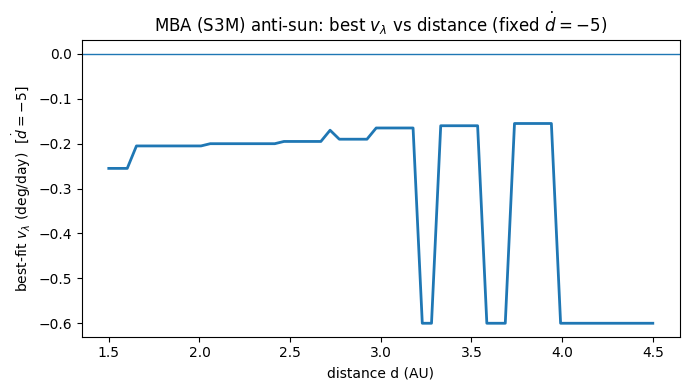

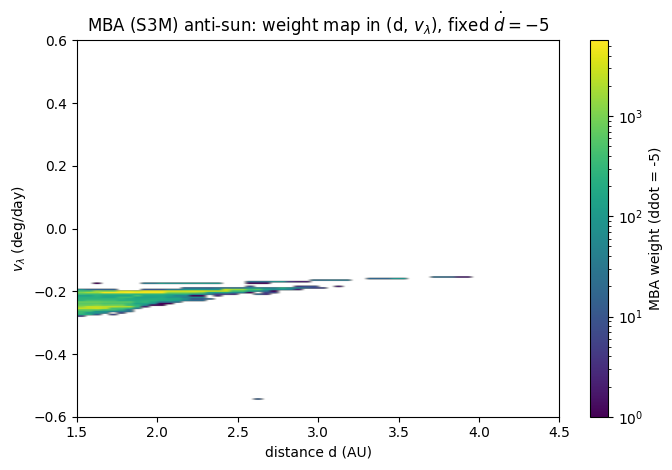

Peak weights: min=0.000e+00, max=5.692e+03


In [85]:

plt.figure(figsize=(7, 4))
plt.plot(d_grid, best_vlam, lw=2)
plt.axhline(0.0, lw=1)
plt.xlabel("distance d (AU)")
plt.ylabel(r"best-fit $v_\lambda$ (deg/day)  [$\dot d = -5$]")
plt.title("MBA (S3M) anti-sun: best $v_\\lambda$ vs distance (fixed $\dot d=-5$)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4.8))
plt.imshow(
    W.T,
    origin="lower",
    aspect="auto",
    extent=[d_grid[0], d_grid[-1], vlam_grid[0], vlam_grid[-1]],
    norm = "log"
)
# add norm = "log" to imshow to see in log space
plt.colorbar(label="MBA weight (ddot = -5)")
plt.xlabel("distance d (AU)")
plt.ylabel(r"$v_\lambda$ (deg/day)")
plt.title("MBA (S3M) anti-sun: weight map in (d, $v_\\lambda$), fixed $\dot d=-5$")
plt.tight_layout()
plt.show()

print(f"Peak weights: min={best_w.min():.3e}, max={best_w.max():.3e}")


Extracting elements on ridge: 100%|██████████| 44/44 [00:00<00:00, 96.72d/s]


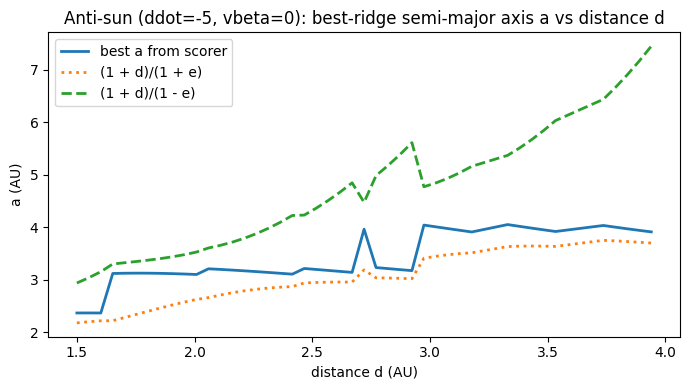

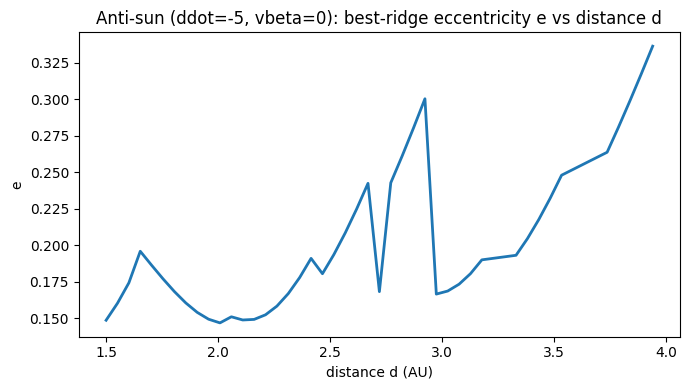

a range: 2.3650433654298566 to 4.048584097373329
e range: 0.14673447113808144 to 0.3364151903474351
i range: 0.0037595936818467283 to 0.004917349544871162
H range: 17.52626234877247 to 21.088581179403448


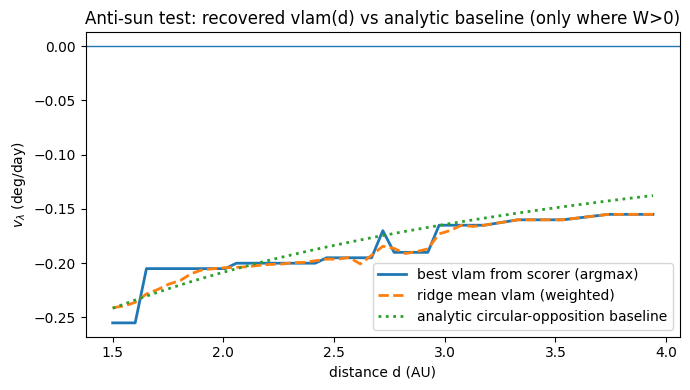

Supported d range: 1.5 to 3.940677966101695
How many supported points: 44 / 60


In [86]:
# mask unsupported distances 
row_max = W.max(axis=1)
mask = row_max > 0

#for opposition, circular coplanar orbit
vE = 0.986  # deg/day
d = d_grid.copy()
R = 1.0 + d
vlam_pred = vE * (1/np.sqrt(R) - 1.0) / d  # deg/day, negative, |vlam| decreases with d

# using "center of mass" of the ridge instead of argmax
# this avoids bin/edge effects if the ridge is broad
Wpos = W.copy()
Wpos[Wpos < 0] = 0 # negative weight clipped to 0
vlam_mean = np.full(len(d_grid), np.nan)
for k in range(len(d_grid)):
    s = Wpos[k].sum()
    if s > 0:
        vlam_mean[k] = np.sum(vlam_grid * Wpos[k]) / s

# Extract orbital elements (a,e,i,H) along the best-vlam ridge vs distance 

a_best = np.full(len(d_grid), np.nan)
e_best = np.full(len(d_grid), np.nan)
i_best = np.full(len(d_grid), np.nan)
H_best = np.full(len(d_grid), np.nan)
score_best = np.full(len(d_grid), np.nan)

for k in tqdm(np.where(mask)[0], desc="Extracting elements on ridge", unit="d"):
    d_au = d_grid[k]
    vlam = best_vlam[k]

    # convert (vlam, vbeta_fixed) -> (dra, ddec) at the anti-sun sky position
    dra, ddec = nsc.ecliptic_rates_to_radec_rates1(
        ra0_deg, dec0_deg, vlam, vbeta_fixed, obstime_str
    )

    out = scorer_mba_s3m.compute_score(
        obstime_str=obstime_str,
        ra_deg=ra0_deg,
        dec_deg=dec0_deg,
        dra_deg_per_day=dra,
        ddec_deg_per_day=ddec,
        mag=mag,
        d_au=d_au,
        ddot_kms=ddot_fixed
    )

    score_best[k] = out["score"]
    a_best[k] = out["a"]
    e_best[k] = out["e"]
    i_best[k] = out["i"]
    H_best[k] = out["H"]

# Plot a vs d (only where supported)
plt.figure(figsize=(7,4))

# main curve
plt.plot(d_grid[mask], a_best[mask], lw=2, label="best a from scorer")

# plots the upper and lower range
plt.plot(d_grid[mask], (1 + d_grid[mask])/(1 + e_best[mask]),
         ls=":", lw=2, label="(1 + d)/(1 + e)")
plt.plot(d_grid[mask], (1 + d_grid[mask])/(1 - e_best[mask]),
         ls="--", lw=2, label="(1 + d)/(1 - e)")

#plt.plot(d_grid[mask], a_best[mask], lw=2)
plt.xlabel("distance d (AU)")
plt.ylabel("a (AU)")
plt.title("Anti-sun (ddot=-5, vbeta=0): best-ridge semi-major axis a vs distance d")
plt.tight_layout()
plt.legend()
plt.show()

# plotting e vs d
plt.figure(figsize=(7,4))
plt.plot(d_grid[mask], e_best[mask], lw=2)
plt.xlabel("distance d (AU)")
plt.ylabel("e")
plt.title("Anti-sun (ddot=-5, vbeta=0): best-ridge eccentricity e vs distance d")
plt.tight_layout()
plt.show()



print("a range:", np.nanmin(a_best), "to", np.nanmax(a_best))
print("e range:", np.nanmin(e_best), "to", np.nanmax(e_best))
print("i range:", np.nanmin(i_best), "to", np.nanmax(i_best))
print("H range:", np.nanmin(H_best), "to", np.nanmax(H_best))


# plot comparison only where supported aka no zero
plt.figure(figsize=(7,4))
plt.plot(d_grid[mask], best_vlam[mask], lw=2, label="best vlam from scorer (argmax)")
plt.plot(d_grid[mask], vlam_mean[mask], lw=2, ls="--", label="ridge mean vlam (weighted)")
plt.plot(d_grid[mask], vlam_pred[mask], lw=2, ls=":", label="analytic circular-opposition baseline")

plt.axhline(0, lw=1)
plt.xlabel("distance d (AU)")
plt.ylabel(r"$v_\lambda$ (deg/day)")
plt.title("Anti-sun test: recovered vlam(d) vs analytic baseline (only where W>0)")
plt.legend()
plt.tight_layout()
plt.show()

print("Supported d range:", d_grid[mask].min(), "to", d_grid[mask].max())
print("How many supported points:", mask.sum(), "/", len(mask))
